# Lección 3.1 · Dot plots: ver la similitud antes de medirla

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-03-alineamiento/3.1_dot_plots.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 3 — Alineamiento de secuencias** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Introductorio–intermedio | Lecciones 0.1–0.3, 1.1–1.3 y 2.1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Construir** un *dot plot* (gráfico de puntos) a mano y con `numpy`, entendiendo cada punto como una pregunta
   "¿esta letra de la secuencia A es igual a esta letra de la secuencia B?".
2. **Leer** los patrones de un *dot plot*: diagonales (similitud), diagonales desplazadas (inserciones y deleciones),
   diagonales paralelas (repeticiones en tándem), antidiagonales (repeticiones invertidas), bloques (baja complejidad)
   y segmentos intercambiados (reordenamientos).
3. **Calcular** cuántos puntos aparecen **por puro azar** ($p=\sum_i p_i^2$, $p^k$ y el modelo binomial de ventanas)
   y **elegir** el tamaño de palabra o de ventana que borra el ruido sin borrar la señal.
4. **Comparar** dos genomas reales (SARS-CoV-2 y SARS-CoV-1) y **descubrir** dónde divergieron.
5. **Detectar** repeticiones internas en una proteína real (los cuatro "manos EF" de la calmodulina) y estructuras
   en horquilla en el ADN.
6. **Explicar** por qué el *dot plot* es el punto de partida del alineamiento, y qué le falta para ser un método
   cuantitativo (Lección 3.2).

## 🗺️ Mapa de la clase

1. Una tabla para comparar dos textos
2. 🎬 Ver cómo se llena la tabla, fila por fila
3. El catálogo de patrones: aprender a leer un *dot plot*
4. El enemigo: los puntos que aparecen por azar
5. Dos filtros contra el ruido: palabras de $k$ letras y ventanas con umbral
6. 🧪 Experimento: SARS-CoV-2 frente a SARS-CoV-1
7. 🧪 Experimento: las repeticiones internas de la calmodulina
8. 🧪 Horquillas y palíndromos: comparar una secuencia con su complemento reverso
9. Lo que un *dot plot* no puede decirnos (y por qué necesitamos alinear)
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import time
from collections import Counter, defaultdict
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.gridspec import GridSpec

try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO, Entrez
Entrez.email = "su.correo@ejemplo.com"     # ← escriba aquí su correo (el NCBI lo pide)
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

Entorno listo ✔  |  Colab: False


## 1. Una tabla para comparar dos textos

Imagine que tiene dos versiones de una misma receta, copiadas a mano por dos personas distintas a lo largo de los
años. Quiere saber **qué partes se conservaron, qué partes se perdieron y qué partes se agregaron**. La forma más
honesta de empezar, sin ninguna teoría, es **mirar**: poner un texto a lo largo de una hoja, el otro hacia abajo, y
marcar cada cruce donde las dos letras coinciden. Eso es un **dot plot** (gráfico de puntos o matriz de puntos),
propuesto por Gibbs y McIntyre en 1970, y todavía hoy es la primera figura que un bioinformático dibuja cuando
recibe dos secuencias.

La receta es muy sencilla:

1. Escriba la secuencia $A$ en el eje horizontal (una letra por columna).
2. Escriba la secuencia $B$ en el eje vertical, de arriba hacia abajo (una letra por fila).
3. En cada casilla $(i, j)$ ponga un punto **si y sólo si** $A_i = B_j$.

Formalmente, el *dot plot* es una matriz de ceros y unos:

$$
D_{ij} \;=\;
\begin{cases}
1 & \text{si } A_i = B_j \\[2pt]
0 & \text{si } A_i \neq B_j
\end{cases}
\qquad\qquad i = 1,\dots,n, \quad j = 1,\dots,m
$$

| Símbolo | Significado |
|---|---|
| $A,\ B$ | las dos secuencias que comparamos |
| $n,\ m$ | sus longitudes |
| $A_i$ | la letra en la posición $i$ de $A$ (columna $i$) |
| $B_j$ | la letra en la posición $j$ de $B$ (fila $j$) |
| $D_{ij}$ | la casilla de la tabla: 1 = punto, 0 = vacío |

### Un ejemplo a mano

Comparemos `GATTACA` con `GATCACA` (difieren en una sola letra, la cuarta). Antes de ver la figura, haga el ejercicio
mental: la fila 1 corresponde a la `G` de $B$; ¿en qué columnas de $A$ hay una `G`? Sólo en la columna 1. La fila 2
es una `A`: hay `A` en las columnas 2, 5 y 7, así que esa fila tiene **tres** puntos. Siga así fila por fila.

Lo importante es lo que aparece al final: cuando las dos secuencias son parecidas, los puntos **se alinean en una
diagonal**. ¿Por qué una diagonal? Porque si $A_i = B_j$ y la similitud continúa, entonces también $A_{i+1} = B_{j+1}$:
avanzar una letra en ambas secuencias es moverse una casilla a la derecha **y** una hacia abajo.

In [2]:
def dot_matrix(a: str, b: str) -> np.ndarray:
    """Matriz de puntos D[i, j] = (a[i] == b[j]) usando broadcasting de numpy."""
    A = np.frombuffer(a.encode(), dtype=np.uint8)
    B = np.frombuffer(b.encode(), dtype=np.uint8)
    return A[:, None] == B[None, :]          # forma (len(a), len(b)): filas = a, columnas = b

a, b = "GATTACA", "GATCACA"
D = dot_matrix(a, b)
print(D.astype(int))
print("Puntos totales:", D.sum(), " · puntos en la diagonal principal:", np.trace(D))

[[1 0 0 0 0 0 0]
 [0 1 0 0 1 0 1]
 [0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 1 0 0 1 0 1]
 [0 0 0 1 0 1 0]
 [0 1 0 0 1 0 1]]
Puntos totales: 14  · puntos en la diagonal principal: 6


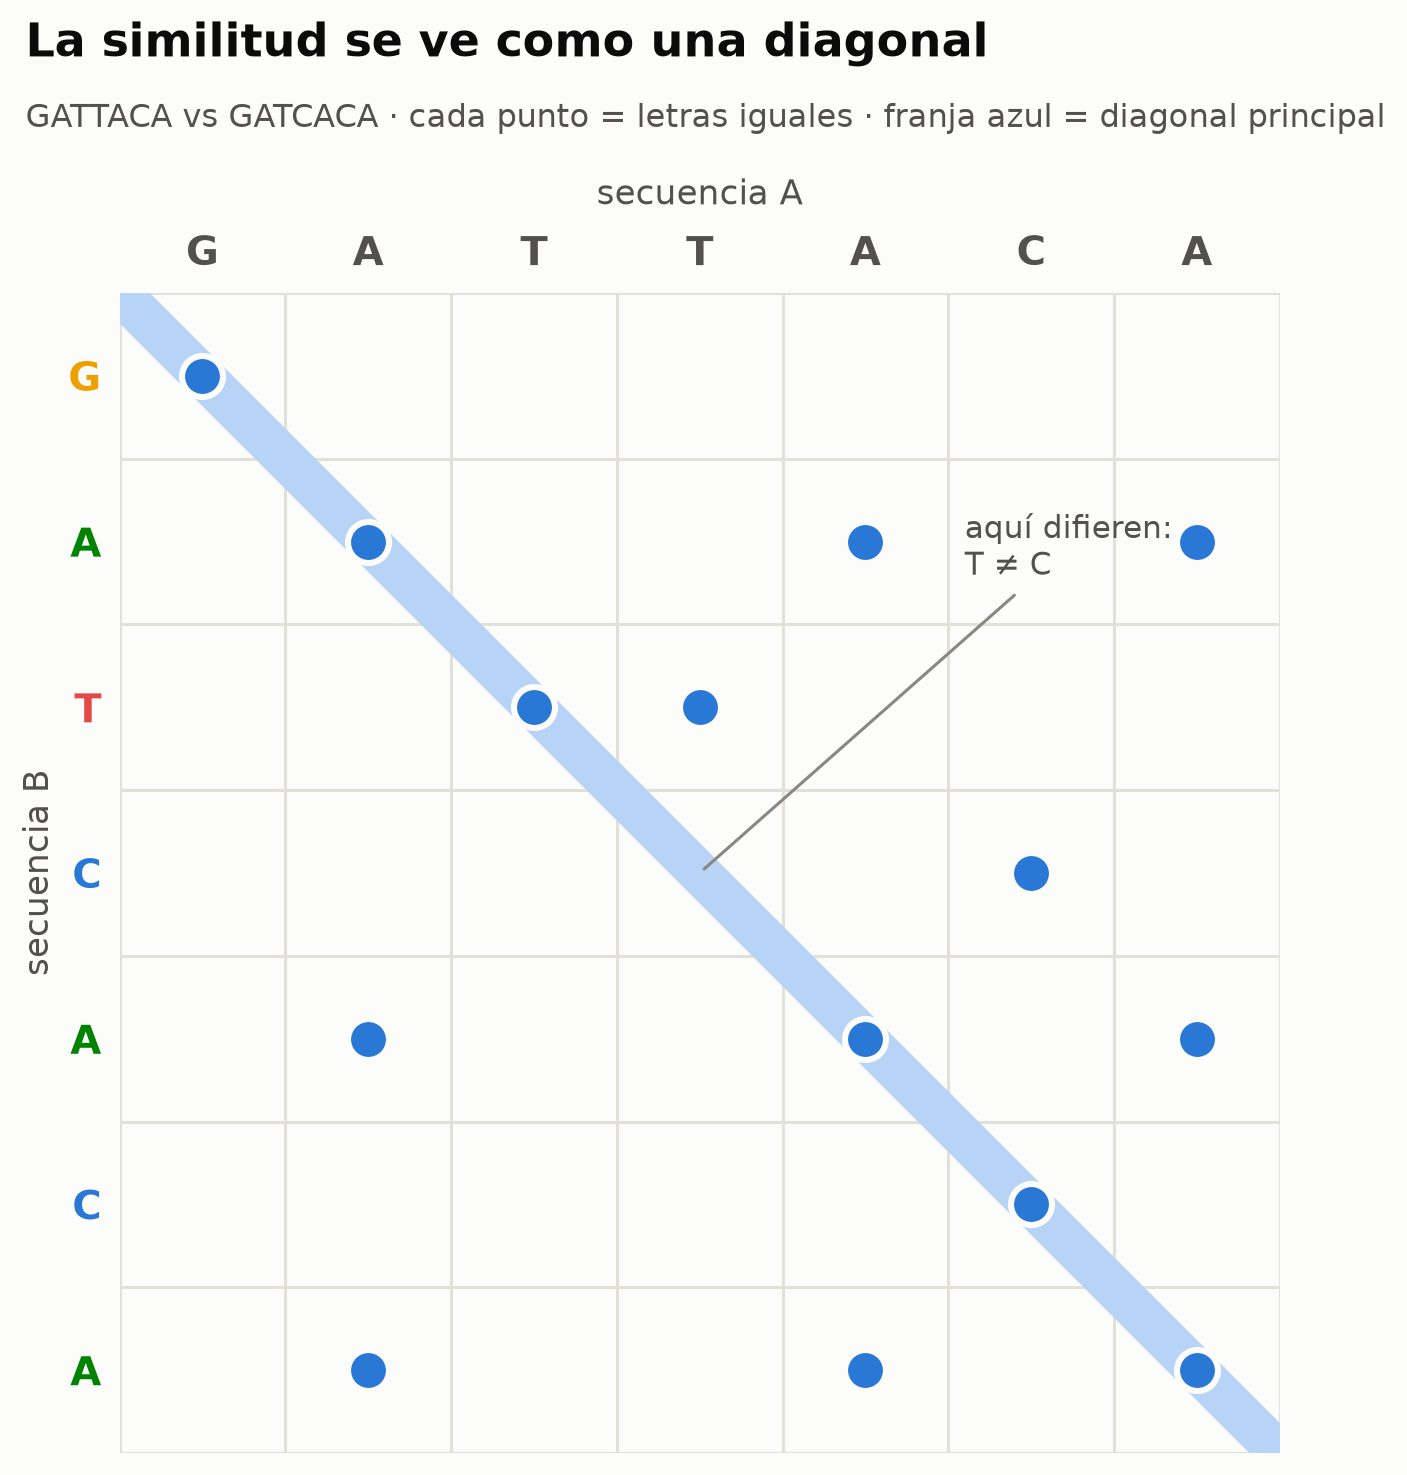

In [3]:
def draw_small_dotplot(ax, a, b, D, highlight_diag=True):
    """Dibuja un dot plot pequeño con las letras en los ejes (x = a, y = b hacia abajo)."""
    n, m = len(a), len(b)
    for k in range(n + 1):
        ax.axvline(k - 0.5, color=ec.GRID, lw=1, zorder=0)
    for k in range(m + 1):
        ax.axhline(k - 0.5, color=ec.GRID, lw=1, zorder=0)
    if highlight_diag:
        ax.plot([-0.5, min(n, m) - 0.5], [-0.5, min(n, m) - 0.5], color=ec.SEQ_BLUE[1], lw=14,
                solid_capstyle="butt", zorder=1)
    ii, jj = np.nonzero(D)
    ax.scatter(ii, jj, s=180, color=ec.BLUE, edgecolor=ec.SURFACE, linewidth=2, zorder=3)
    ax.set_xticks(range(n)); ax.set_xticklabels(list(a), fontsize=13, fontweight="bold")
    ax.set_yticks(range(m)); ax.set_yticklabels(list(b), fontsize=13, fontweight="bold")
    for t, base in zip(ax.get_xticklabels(), a):
        t.set_color(ec.NUC_COLORS.get(base, ec.INK))
    for t, base in zip(ax.get_yticklabels(), b):
        t.set_color(ec.NUC_COLORS.get(base, ec.INK))
    ax.xaxis.tick_top()
    ax.set_xlim(-0.5, n - 0.5); ax.set_ylim(m - 0.5, -0.5)
    ax.set_aspect("equal"); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)

fig, ax = plt.subplots(figsize=(5.8, 6.2))
draw_small_dotplot(ax, a, b, D)
ax.annotate("aquí difieren:\nT ≠ C", xy=(3, 3), xytext=(4.6, 1.2), fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax.set_xlabel("secuencia A", color=ec.INK_2, labelpad=10); ax.xaxis.set_label_position("top")
ax.set_ylabel("secuencia B", color=ec.INK_2)
ec.fig_title(fig, "La similitud se ve como una diagonal",
             "GATTACA vs GATCACA · cada punto = letras iguales · franja azul = diagonal principal")
plt.show()

> 🔎 **Qué observamos.** La diagonal principal tiene 6 de 7 puntos: el hueco en la casilla $(4,4)$ es exactamente la
> letra que cambió (`T` → `C`). Pero también hay **puntos fuera de la diagonal**: por ejemplo, la `A` de la fila 2
> coincide con las `A` de las columnas 5 y 7. Esos puntos no significan nada biológico; aparecen porque el alfabeto
> tiene sólo 4 letras y las coincidencias casuales son inevitables. Ese "ruido" será el protagonista de la sección 4.

> ✅ **Compruebe su comprensión.** Sin ejecutar código: si comparáramos `GATTACA` consigo misma, ¿cuántos puntos
> tendría la diagonal principal? ¿Sería la matriz simétrica? (Respuesta: 7, y sí, porque $D_{ij}=D_{ji}$ cuando $A=B$.)

## 2. 🎬 Ver cómo se llena la tabla, fila por fila

La computadora no "ve" la diagonal: la construye pregunta por pregunta. Para cada letra de $B$ (cada fila) recorre
todas las letras de $A$ y marca las coincidencias. Con dos secuencias de 18 letras son $18 \times 18 = 324$
preguntas. La animación muestra ese proceso; observe cómo la diagonal **emerge** poco a poco entre puntos sueltos.

![El dot plot se llena fila por fila: la diagonal de similitud emerge entre puntos casuales.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.1_llenado.gif)

*El dot plot se llena fila por fila: la diagonal de similitud emerge entre puntos casuales.*

In [4]:
a_anim = "ACGTTGCAAGGCTTACGA"
b_anim = "TTACGTAGCAAGGCTACG"
D_anim = dot_matrix(a_anim, b_anim)
n, m = len(a_anim), len(b_anim)

fig, ax = plt.subplots(figsize=(6.4, 6.6))
for k in range(n + 1): ax.axvline(k - 0.5, color=ec.GRID, lw=0.8, zorder=0)
for k in range(m + 1): ax.axhline(k - 0.5, color=ec.GRID, lw=0.8, zorder=0)
ax.set_xticks(range(n)); ax.set_xticklabels(list(a_anim), fontsize=11, fontweight="bold")
ax.set_yticks(range(m)); ax.set_yticklabels(list(b_anim), fontsize=11, fontweight="bold")
for t, base in zip(ax.get_xticklabels(), a_anim): t.set_color(ec.NUC_COLORS[base])
for t, base in zip(ax.get_yticklabels(), b_anim): t.set_color(ec.NUC_COLORS[base])
ax.xaxis.tick_top(); ax.set_xlim(-0.5, n - 0.5); ax.set_ylim(m - 0.5, -0.5)
ax.set_aspect("equal"); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
from matplotlib.patches import Rectangle
row_band = Rectangle((-0.5, -0.5), n, 1, color=ec.SEQ_BLUE[0], zorder=0)
ax.add_patch(row_band)
dots = ax.scatter([], [], s=120, color=ec.BLUE, edgecolor=ec.SURFACE, linewidth=1.5, zorder=3)
counter = ax.text(0, m + 0.3, "", fontsize=11, color=ec.INK_2, va="top")
# El camino verdadero de similitud (se revela en los cuadros finales): (columna en A, fila en B)
true_path_x = [0, 3, np.nan, 5, 12, np.nan, 14, 16]
true_path_y = [2, 5, np.nan, 7, 14, np.nan, 15, 17]
path_line, = ax.plot([], [], color=ec.ORANGE, lw=10, alpha=0.35, solid_capstyle="round", zorder=2)
ax.set_title("Construyendo el dot plot: una fila por cuadro", loc="left", pad=28, fontsize=13)

frames = list(range(m)) + [m - 1] * 6          # pausa al final

def update(f):
    row = frames[f]
    row_band.set_y(row - 0.5)                          # mueve la franja a la fila actual
    ii, jj = np.nonzero(D_anim[:, :row + 1])          # columnas de A, filas de B ya procesadas
    dots.set_offsets(np.column_stack([ii, jj]) if len(ii) else np.empty((0, 2)))
    counter.set_text(f"fila {row + 1} de {m} · preguntas hechas: {(row + 1) * n} · puntos: {len(ii)}")
    if f >= m:                                         # cuadros finales: revelar la similitud verdadera
        path_line.set_data(true_path_x, true_path_y)
        counter.set_text(f"{len(ii)} puntos · en naranja, los tramos de similitud verdadera")
    else:
        path_line.set_data([], [])
    return dots, counter, path_line

ec.animate(fig, update, frames=len(frames), interval=260, name="3.1_llenado")

> 🔎 **Qué observamos.** Con secuencias tan cortas el ruido es denso (82 puntos de 324 casillas, casi 1 de cada 4, como
> predice la sección 4) y la diagonal cuesta verla; por eso en los últimos cuadros la resaltamos en naranja. Es una
> diagonal larga desplazada: la región `ACG…CTTACG` de $A$ coincide con
> la región `ACG…CTACG` de $B$, pero **empieza en otra posición** (por eso la diagonal no pasa por la esquina). Y cerca
> del final la diagonal "salta" una casilla: $A$ tiene una `T` extra (`GCTTAC` frente a `GCTAC`). Ése es el aspecto de
> una **inserción/deleción** en un *dot plot*: un pequeño escalón que desplaza la diagonal.

## 3. El catálogo de patrones: aprender a leer un *dot plot*

Un radiólogo aprende a leer radiografías viendo cientos de casos; un bioinformático aprende a leer *dot plots* de la
misma forma. Vamos a **fabricar** secuencias con eventos evolutivos conocidos y ver qué huella deja cada uno. Así,
cuando vea una comparación real, sabrá reconocer lo que ocurrió.

Para que la figura sea limpia usaremos un truco que justificaremos en la sección 5: en vez de comparar letras
sueltas, marcaremos un punto sólo cuando coinciden **palabras** de $k = 8$ letras seguidas. Además, como el ADN tiene
**dos hebras**, compararemos $A$ con $B$ (puntos azules, misma hebra) y también $A$ con el **complemento reverso**
de $B$ (puntos naranja, hebra opuesta).

| Evento evolutivo | Cómo se construye | Huella esperada |
|---|---|---|
| Secuencias idénticas | $B = A$ | una diagonal completa |
| Inserción | se agregan 30 letras nuevas en $B$ | la diagonal se corta y continúa **desplazada** |
| Repetición en tándem | un bloque de 20 letras repetido 4 veces | **diagonales paralelas** alrededor de la principal |
| Inversión | un tramo de $B$ se invierte y complementa | un segmento **antidiagonal** naranja |
| Baja complejidad | un tramo `ATATAT…` en ambas | un **bloque** relleno (cuadro sólido) |
| Reordenamiento | las dos mitades de $A$ intercambiadas en $B$ | dos segmentos diagonales **en otras esquinas** |

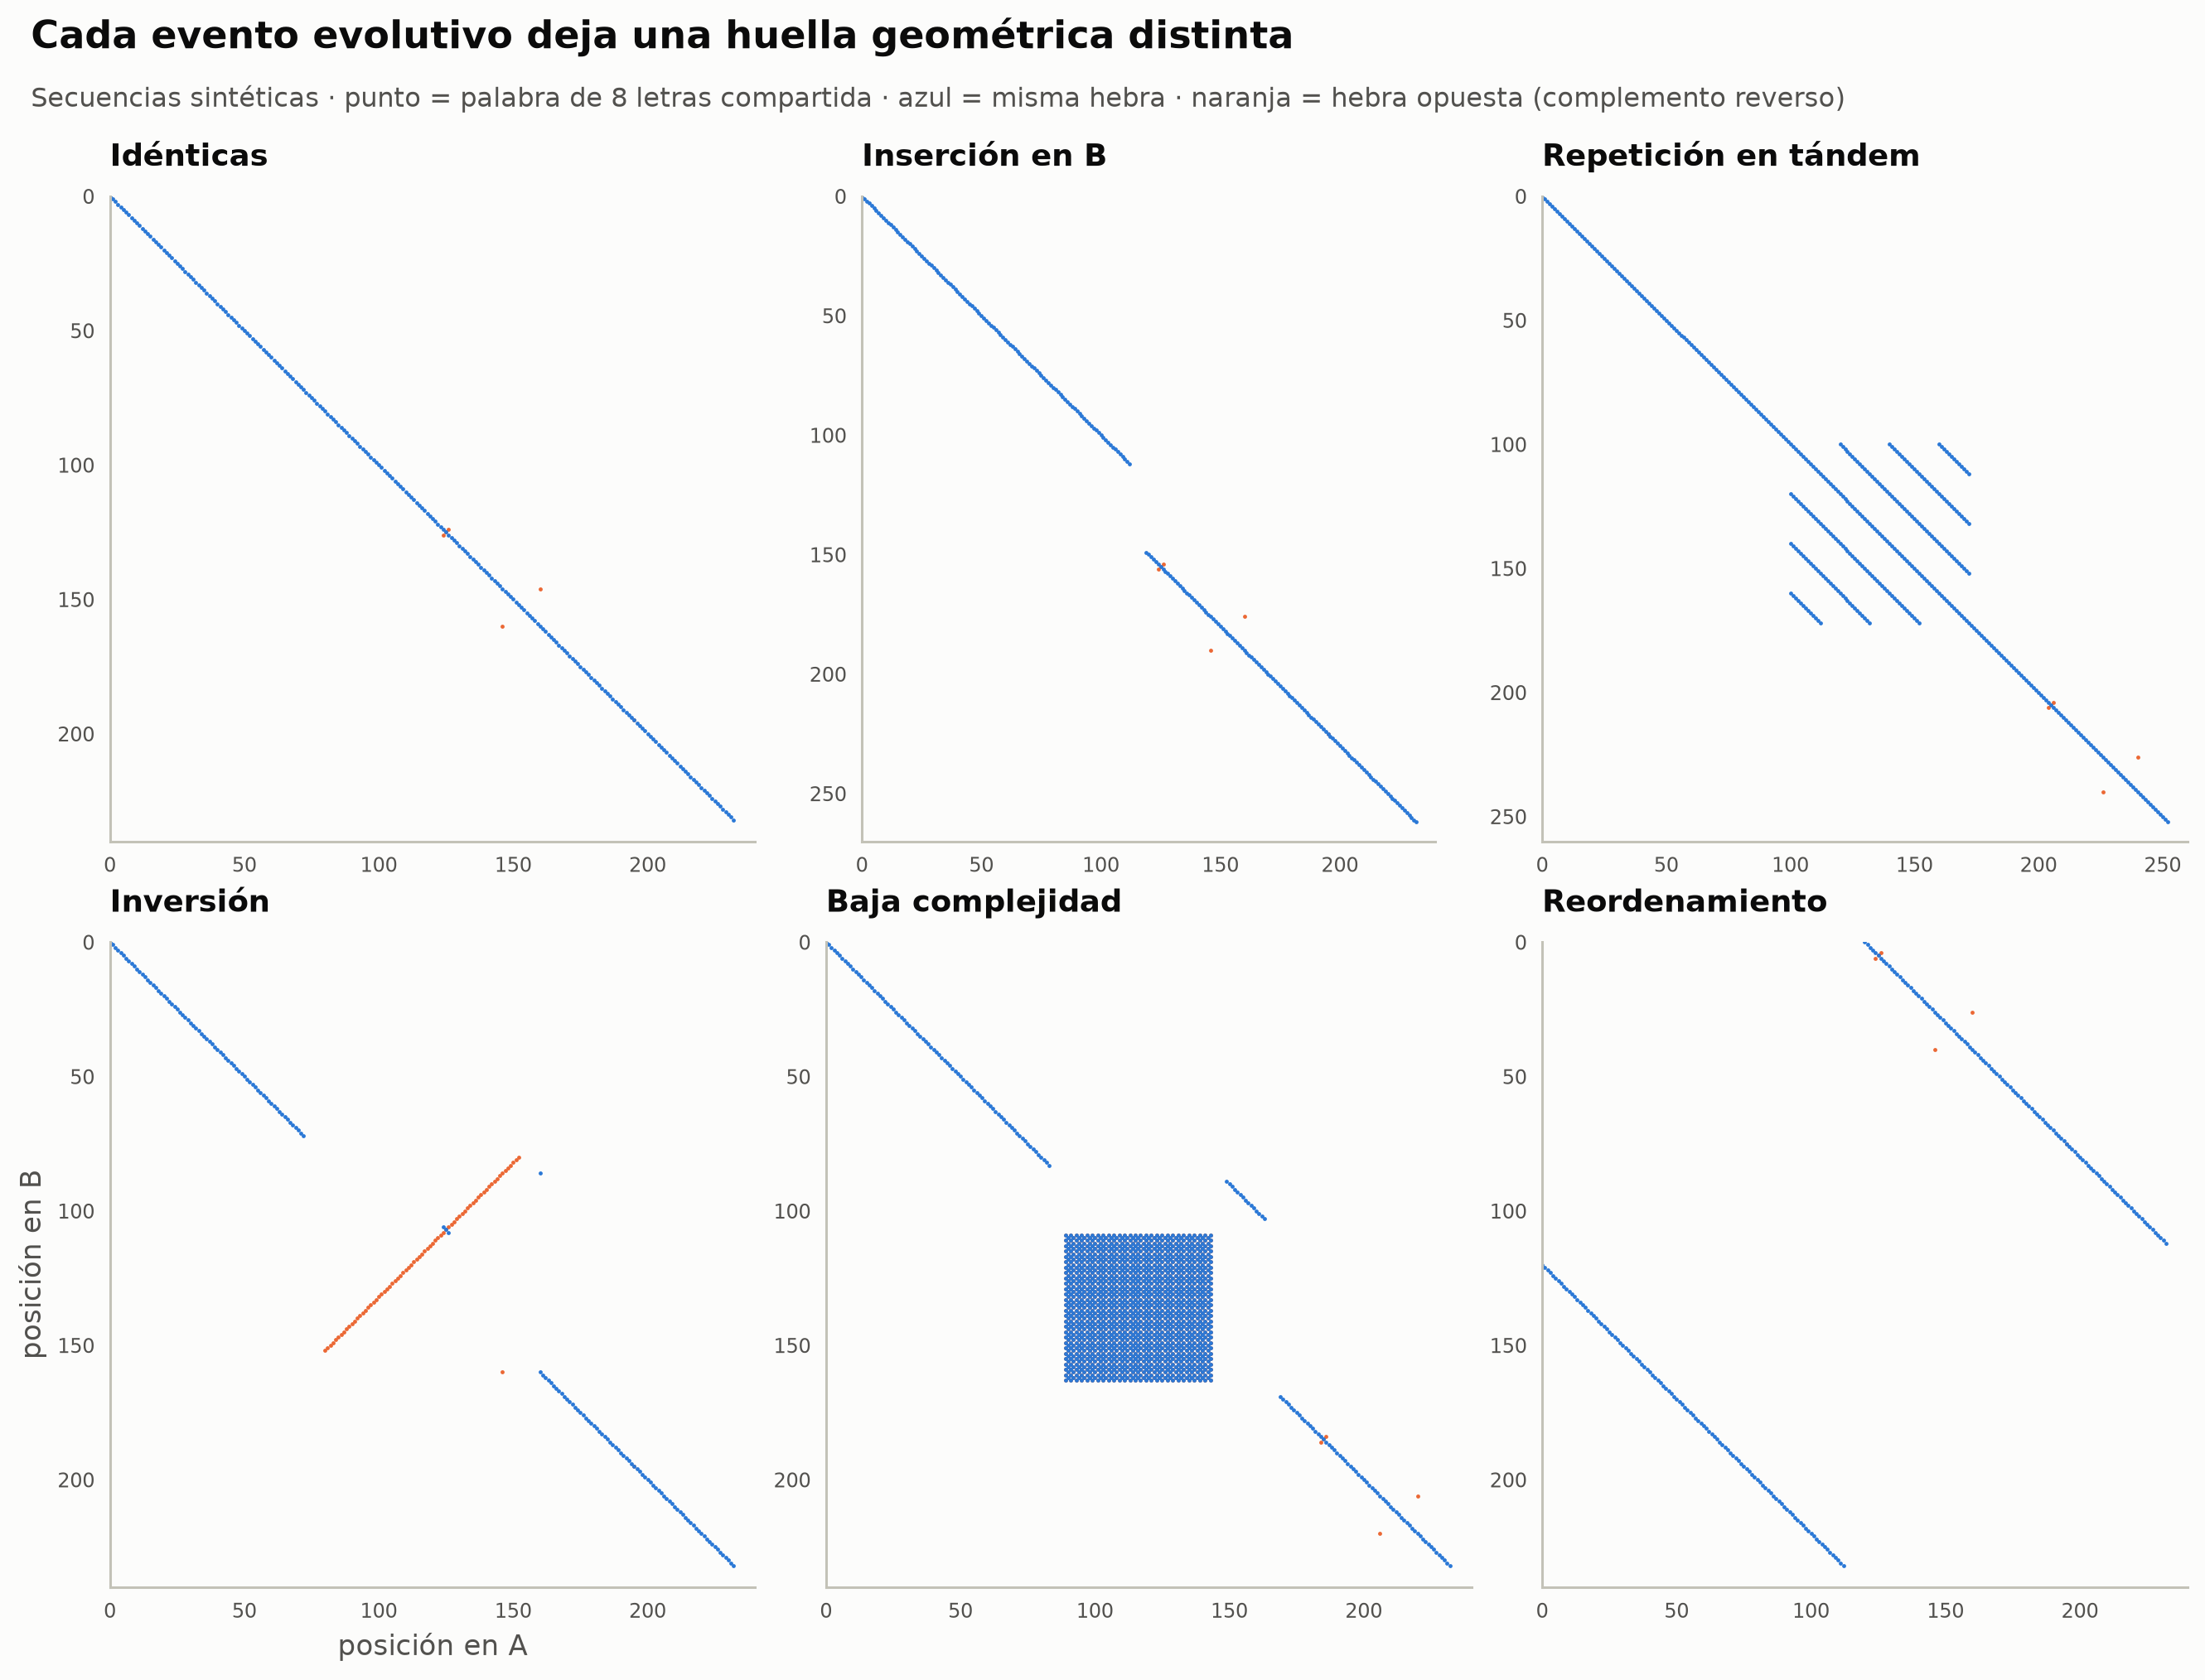

In [5]:
COMP = str.maketrans("ACGT", "TGCA")

def revcomp(s: str) -> str:
    return s.translate(COMP)[::-1]

def kmer_index(s: str, k: int) -> dict:
    """Diccionario palabra -> lista de posiciones donde aparece en s."""
    idx = defaultdict(list)
    for j in range(len(s) - k + 1):
        idx[s[j:j + k]].append(j)
    return idx

def kmer_matches(a: str, b: str, k: int, strand: str = "+"):
    """Posiciones (i en a, j en b) donde coincide una palabra de k letras.
    strand='-' compara a con el complemento reverso de b y devuelve j en coordenadas de b."""
    target = b if strand == "+" else revcomp(b)
    idx = kmer_index(target, k)
    xs, ys = [], []
    for i in range(len(a) - k + 1):
        for j in idx.get(a[i:i + k], ()):
            xs.append(i)
            ys.append(j if strand == "+" else len(b) - k - j)
    return np.array(xs, dtype=int), np.array(ys, dtype=int)

rng = np.random.default_rng(31)
def random_dna(n, rng=rng):
    return "".join(rng.choice(list("ACGT"), size=n))

base = random_dna(240)
unit = random_dna(20)
cases = {
    "Idénticas":             (base, base),
    "Inserción en B":        (base, base[:120] + random_dna(30) + base[120:]),
    "Repetición en tándem":  (base[:100] + unit * 4 + base[100:180], base[:100] + unit * 4 + base[100:180]),
    "Inversión":             (base, base[:80] + revcomp(base[80:160]) + base[160:]),
    "Baja complejidad":      (base[:90] + "AT" * 30 + base[90:180], base[:110] + "AT" * 30 + base[110:180]),
    "Reordenamiento":        (base, base[120:] + base[:120]),
}

def plot_dotplot(ax, a, b, k=8, both=True, s=2.5):
    if both:                                     # primero la hebra opuesta, para que la misma hebra quede encima
        x, y = kmer_matches(a, b, k, "-")
        ax.scatter(x, y, s=s, color=ec.ORANGE, lw=0, rasterized=True)
    x, y = kmer_matches(a, b, k, "+")
    ax.scatter(x, y, s=s, color=ec.BLUE, lw=0, rasterized=True)
    ax.set_xlim(0, len(a)); ax.set_ylim(len(b), 0)
    ax.set_aspect("equal"); ax.grid(False)
    ax.tick_params(labelsize=8)

fig, axes = plt.subplots(2, 3, figsize=(12, 8.4))
for ax, (name, (sa, sb)) in zip(axes.flat, cases.items()):
    plot_dotplot(ax, sa, sb)
    ax.set_title(name, fontsize=12)
axes[1, 0].set_xlabel("posición en A"); axes[1, 0].set_ylabel("posición en B")
ec.fig_title(fig, "Cada evento evolutivo deja una huella geométrica distinta",
             "Secuencias sintéticas · punto = palabra de 8 letras compartida · azul = misma hebra · naranja = hebra opuesta (complemento reverso)")
plt.show()

> 🔎 **Qué observamos.**
>
> * **Inserción:** la diagonal se interrumpe y reaparece **más abajo**: las 30 letras nuevas de $B$ empujan todo lo
>   que sigue. La distancia vertical del salto mide el tamaño de la inserción.
> * **Tándem:** además de la diagonal principal aparecen diagonales **paralelas** separadas por 20 posiciones, el
>   tamaño de la unidad repetida; forman un pequeño cuadrado rayado.
> * **Inversión:** el tramo invertido desaparece de la diagonal azul y reaparece como una **antidiagonal naranja**:
>   sólo se ve si comparamos también la hebra opuesta. Si usted olvida el complemento reverso, ¡la inversión parecería
>   una región sin similitud!
> * **Baja complejidad:** `ATATAT…` coincide consigo mismo en cualquier desplazamiento par, por eso llena un bloque
>   casi sólido (en un patrón de tablero de ajedrez). Además `ATAT` es su propio complemento reverso, así que el bloque
>   aparece en **ambas** hebras. Los bloques así suelen ser artefactos que conviene **enmascarar** antes de buscar similitudes.
> * **Reordenamiento:** los dos pedazos siguen siendo similares, pero sus diagonales quedan en esquinas opuestas.

> ✅ **Compruebe su comprensión.** ¿Cómo se vería una **deleción** en $B$ (en lugar de una inserción)? Piense qué
> eje se "acorta". (Respuesta: la diagonal salta **hacia la derecha** en vez de hacia abajo: se saltan columnas de $A$
> que no tienen pareja en $B$.)

## 4. El enemigo: los puntos que aparecen por azar

Vuelva a la tabla de `GATTACA`: había puntos fuera de la diagonal que no significaban nada. Con secuencias cortas
molestan poco, pero con secuencias de miles de letras **tapan** la señal por completo. Necesitamos saber cuántos
esperar.

### ¿Cuál es la probabilidad de que dos letras al azar coincidan?

Piense en dos bolsas con fichas de colores. Si saca una ficha de cada bolsa, la probabilidad de que ambas sean rojas
es $p_{\text{roja}} \times p_{\text{roja}}$; que ambas sean azules, $p_{\text{azul}}^2$; y así con cada color. La
probabilidad de que **coincidan** (del color que sea) es la suma:

$$
p \;=\; \sum_{x \in \mathcal{A}} p_x^{\,2}
$$

| Símbolo | Significado |
|---|---|
| $\mathcal{A}$ | el alfabeto: $\{A, C, G, T\}$ para ADN; 20 aminoácidos para proteínas |
| $p_x$ | frecuencia de la letra $x$ en las secuencias |
| $p$ | probabilidad de que una casilla tenga un punto **por azar** |

**A mano.** Con ADN de composición uniforme, $p_x = 1/4$ para las cuatro bases:
$p = 4 \times (1/4)^2 = 1/4$. **Una de cada cuatro casillas tendrá un punto aunque las secuencias no tengan nada que
ver.** Con proteínas de composición uniforme $p = 20 \times (1/20)^2 = 1/20 = 0.05$ (en la práctica ≈ 0.06, porque
las frecuencias no son iguales).

### ¿Cuántos puntos de ruido esperamos?

Si hay $n \times m$ casillas y cada una tiene probabilidad $p$ de tener un punto:

$$
\mathbb{E}[\text{puntos al azar}] \;=\; n \cdot m \cdot p
$$

Para dos secuencias de 1 000 bases: $1\,000 \times 1\,000 \times 0.25 = 250\,000$ puntos de ruido, frente a sólo
1 000 puntos posibles en la diagonal verdadera. La señal representa el 0.4 % de los puntos. **No hay forma de verla.**

> 🤔 **Antes de ejecutar, prediga.** Vamos a comparar dos secuencias de 400 bases que son **85 % idénticas** (la
> segunda es una copia de la primera con mutaciones). Con letras sueltas ($k = 1$), ¿se verá la diagonal?

p estimado = 0.251 · puntos observados = 40,214 · esperados al azar = 40,234
puntos en la diagonal verdadera = 350 de 400


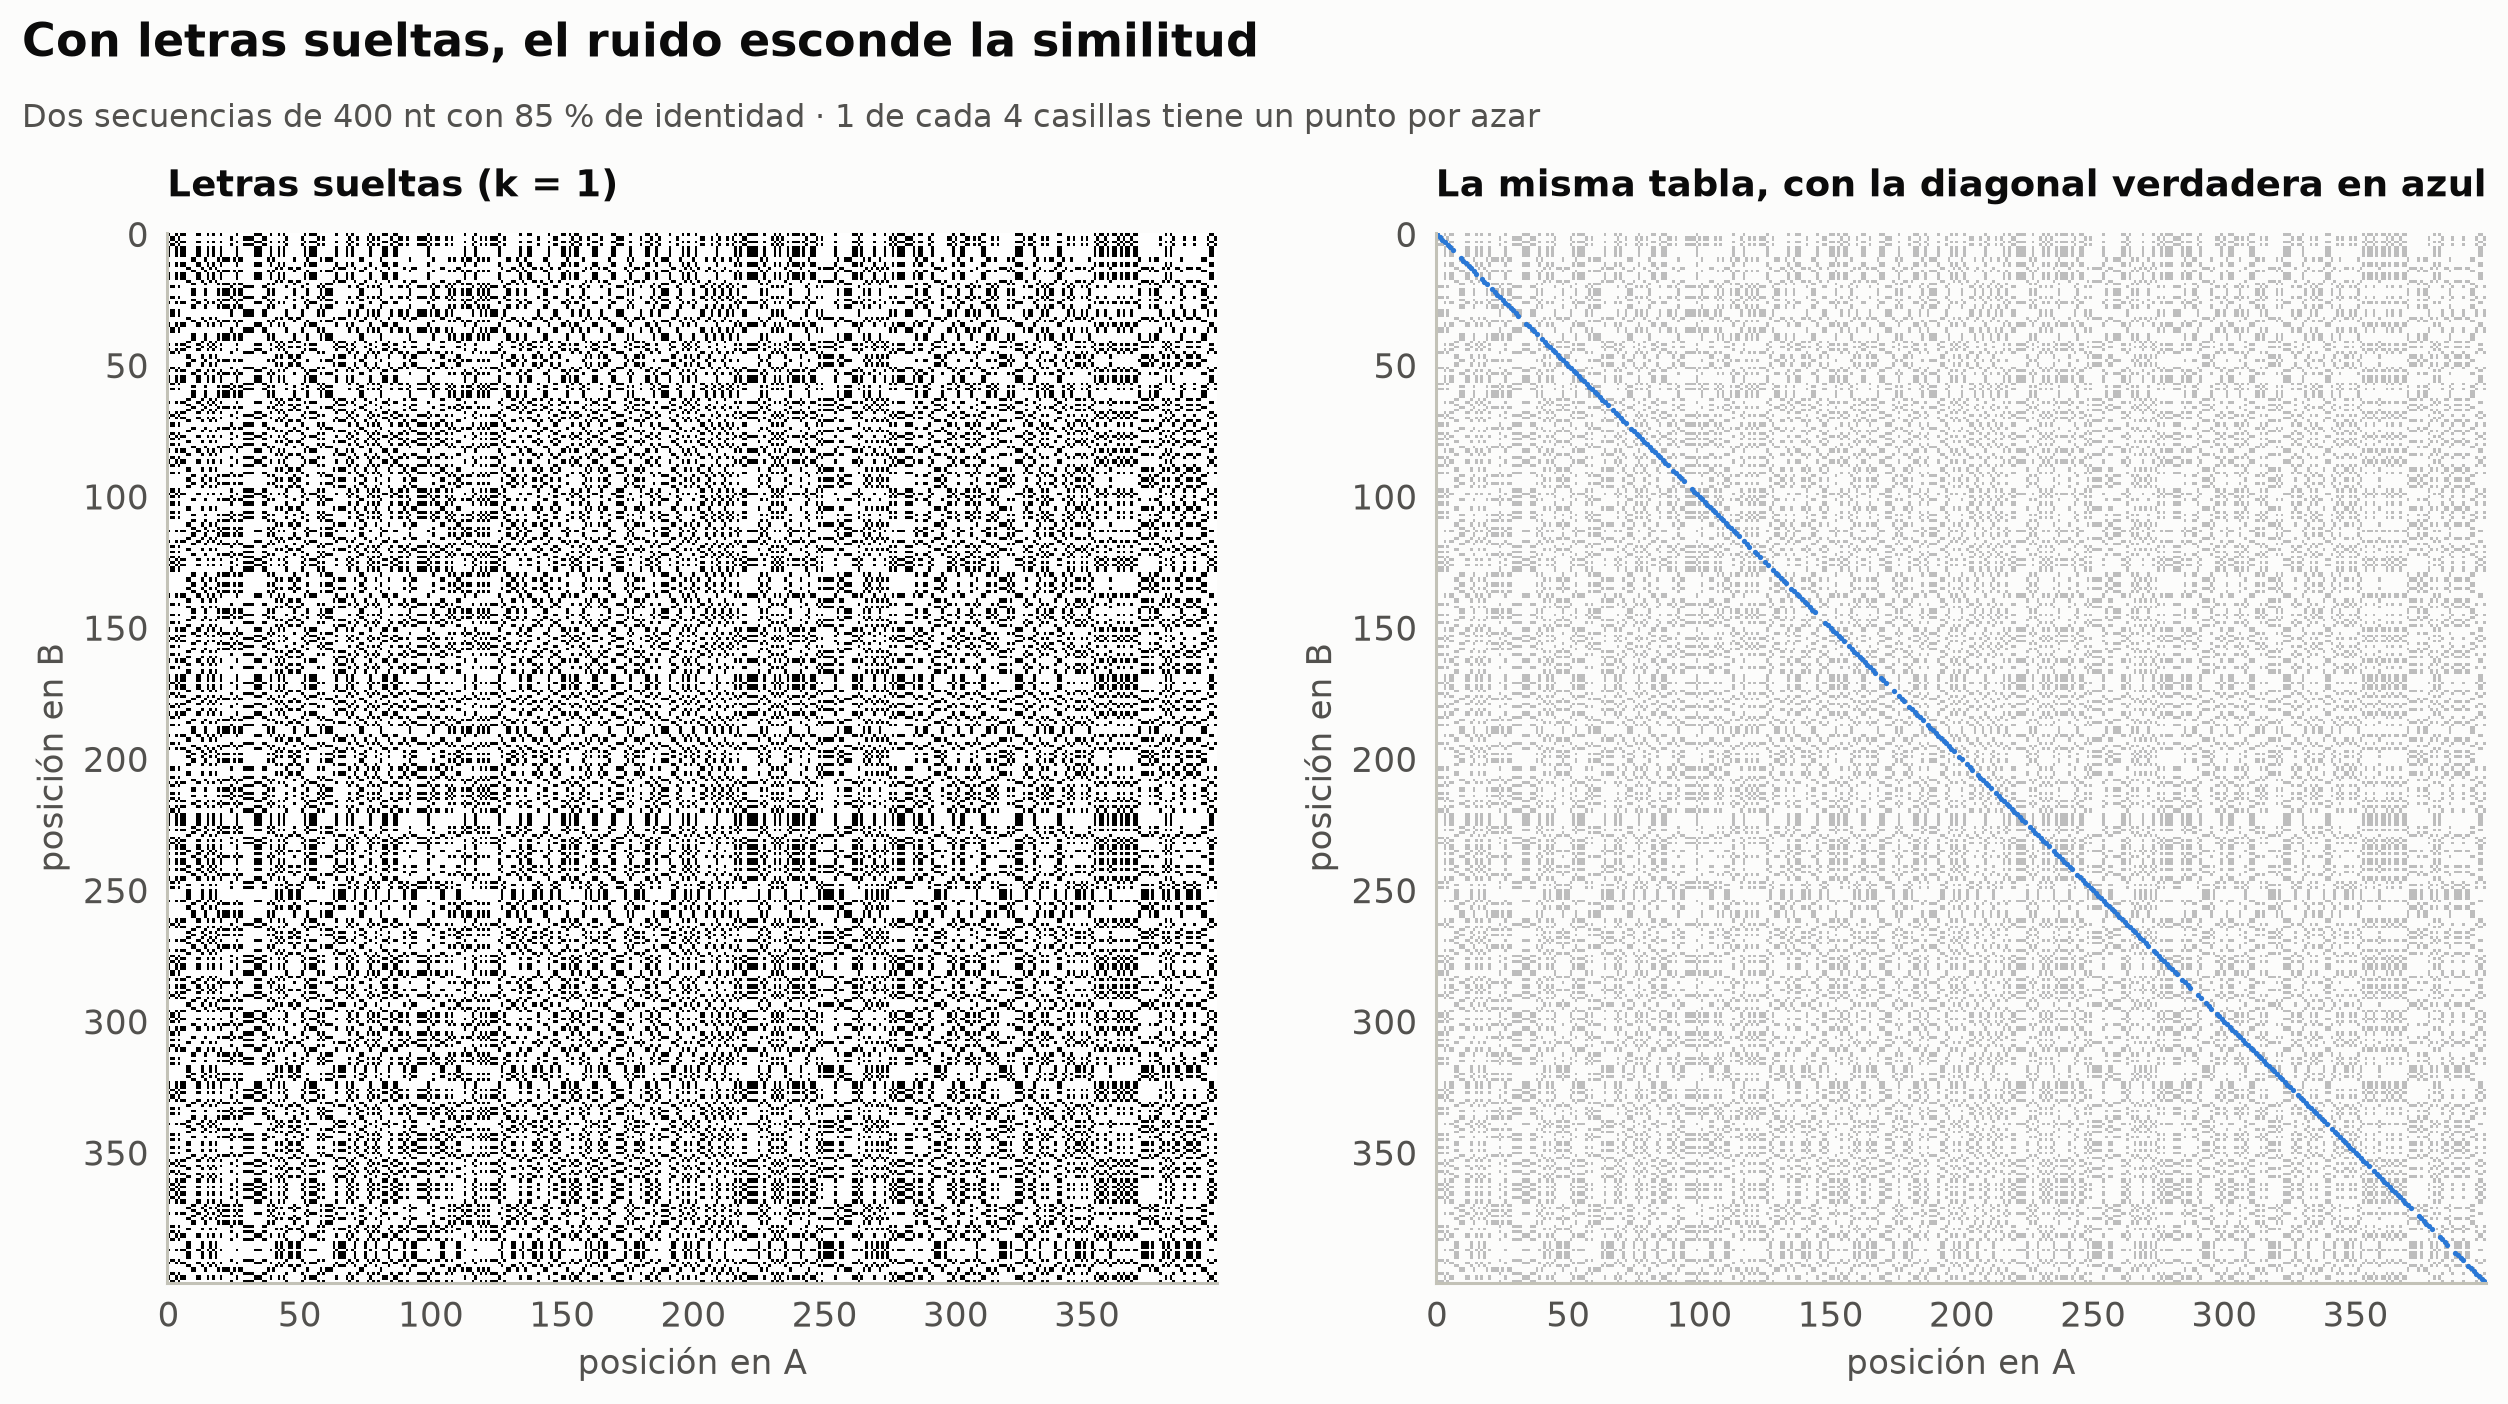

In [6]:
def mutate(seq: str, identity: float, rng) -> str:
    """Copia de seq donde cada base cambia con probabilidad 1 - identity."""
    s = list(seq)
    for i in np.nonzero(rng.random(len(s)) > identity)[0]:
        s[i] = rng.choice([x for x in "ACGT" if x != s[i]])
    return "".join(s)

rng = np.random.default_rng(7)
a400 = random_dna(400, rng)
b400 = mutate(a400, 0.85, rng)
D400 = dot_matrix(a400, b400)

p_letter = sum(v**2 for v in (np.array([a400.count(x) for x in "ACGT"]) / 400))
print(f"p estimado = {p_letter:.3f} · puntos observados = {D400.sum():,} · esperados al azar = {400*400*p_letter:,.0f}")
print(f"puntos en la diagonal verdadera = {np.trace(D400)} de 400")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6))
axes[0].imshow(D400.T, cmap="Greys", interpolation="nearest")
axes[0].set_title("Letras sueltas (k = 1)", fontsize=12)
x, y = kmer_matches(a400, b400, 1)
diag = D400 & np.eye(400, dtype=bool)
axes[1].imshow(D400.T, cmap="Greys", alpha=0.25, interpolation="nearest")
ii = np.nonzero(np.diag(D400))[0]
axes[1].scatter(ii, ii, s=3, color=ec.BLUE, lw=0)
axes[1].set_title("La misma tabla, con la diagonal verdadera en azul", fontsize=12)
for ax in axes:
    ax.set_xlabel("posición en A"); ax.set_ylabel("posición en B"); ax.grid(False)
ec.fig_title(fig, "Con letras sueltas, el ruido esconde la similitud",
             "Dos secuencias de 400 nt con 85 % de identidad · 1 de cada 4 casillas tiene un punto por azar")
plt.show()

> 🔎 **Qué observamos.** La matriz de la izquierda parece "estática de televisor": ~40 000 puntos de ruido contra
> ~340 puntos de señal. La diagonal está ahí (a la derecha la resaltamos en azul), pero el ojo no la encuentra. Hay
> que **filtrar**.

## 5. Dos filtros contra el ruido

### Filtro 1: palabras de $k$ letras

En lugar de preguntar "¿esta letra es igual a esta otra?", preguntamos "¿estas **$k$ letras seguidas** son iguales a
estas otras $k$?". Es lo que hacemos al buscar una palabra en un libro: coincidir en una letra no dice nada;
coincidir en `mitocondria` completa sí.

Si las letras son independientes, que $k$ letras coincidan a la vez tiene probabilidad:

$$
p_k \;=\; p^{\,k}
\qquad\Longrightarrow\qquad
\mathbb{E}[\text{puntos al azar}] \;\approx\; (n-k+1)(m-k+1)\,p^{\,k}
$$

| Símbolo | Significado |
|---|---|
| $k$ | tamaño de la palabra (*word size*) |
| $p^k$ | probabilidad de que una palabra de $k$ letras coincida por azar |
| $(n-k+1)$ | número de palabras que caben en una secuencia de longitud $n$ |

**A mano**, para dos secuencias de ADN de 1 000 bases ($p = 1/4$):

| $k$ | $p^k$ | puntos al azar esperados |
|---|---|---|
| 1 | 0.25 | 250 000 |
| 4 | 0.0039 | ≈ 3 900 |
| 8 | $1.5\times10^{-5}$ | ≈ 15 |
| 11 | $2.4\times10^{-7}$ | ≈ 0.2 |

El ruido cae **exponencialmente** con $k$. Pero la señal también se debilita: si las secuencias tienen identidad
$q$ (por ejemplo 0.85), la probabilidad de que una palabra verdadera sobreviva sin ninguna mutación es $q^k$
($0.85^{8} \approx 0.27$). **Elegir $k$ es negociar entre ruido y sensibilidad.**

> 🤔 **Antes de ejecutar, prediga.** ¿A partir de qué $k$ cree que la diagonal se volverá visible en las secuencias
> de 400 bases de la sección anterior? ¿Y a partir de qué $k$ empezará a **desaparecer** por culpa de las mutaciones?

![Al aumentar el tamaño de palabra k, el ruido se desvanece y la diagonal aparece; si k crece demasiado, la diagonal también se fragmenta.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.1_filtro_k.gif)

*Al aumentar el tamaño de palabra k, el ruido se desvanece y la diagonal aparece; si k crece demasiado, la diagonal también se fragmenta.*

In [7]:
ks = list(range(1, 15))
fig, ax = plt.subplots(figsize=(6.2, 6.6))
sc = ax.scatter([], [], s=3, color=ec.BLUE, lw=0)
ax.set_xlim(0, 400); ax.set_ylim(400, 0); ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("posición en A"); ax.set_ylabel("posición en B")
title = ax.set_title("", loc="left", fontsize=13, pad=26)
sub = ax.text(0, 1.015, "", transform=ax.transAxes, fontsize=10, color=ec.INK_2, va="bottom")
frames = ks + [ks[-1]] * 3

def update(f):
    k = frames[f]
    x, y = kmer_matches(a400, b400, k)
    sc.set_offsets(np.column_stack([x, y]) if len(x) else np.empty((0, 2)))
    sc.set_sizes([6 if k > 3 else 2])
    on_diag = np.sum(x == y)
    expected = (401 - k) ** 2 * p_letter ** k
    title.set_text(f"Palabras de k = {k} letras")
    sub.set_text(f"puntos: {len(x):,} · en la diagonal: {on_diag} · ruido esperado: {expected:,.1f}")
    return sc, title, sub

ec.animate(fig, update, frames=len(frames), interval=650, name="3.1_filtro_k")

Comprobemos la teoría con un experimento más grande: dos secuencias **sin ninguna relación** de 2 000 bases.
Contamos cuántas palabras compartidas hay para cada $k$ y comparamos con $(n-k+1)(m-k+1)\,p^k$. Para contar rápido
usamos un truco: si la palabra $w$ aparece $c_A(w)$ veces en $A$ y $c_B(w)$ veces en $B$, forma $c_A(w)\cdot c_B(w)$
puntos, así que el total es $\sum_w c_A(w)\, c_B(w)$ — sin recorrer toda la tabla.

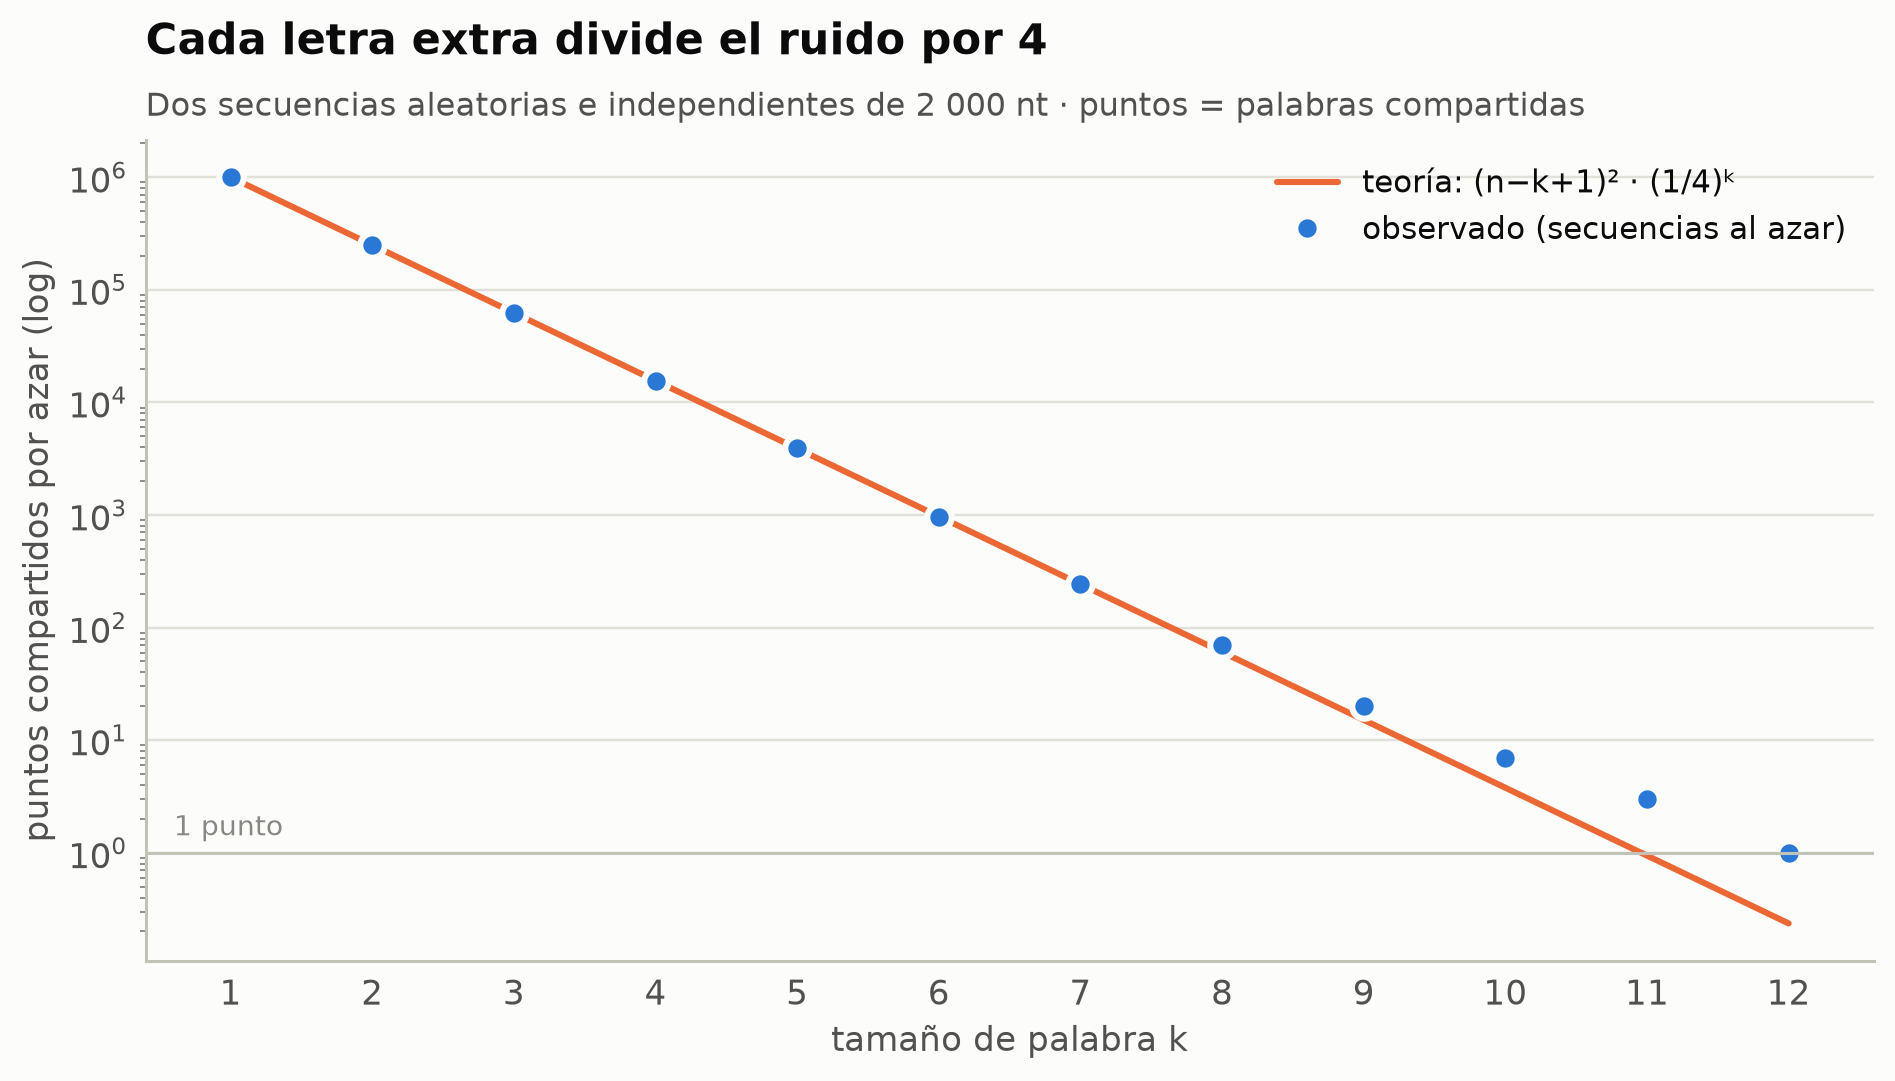

,k,observed,expected
0,1,999540,1000000.0
1,2,249723,249750.1
2,3,62411,62375.1
3,4,15578,15578.2
4,5,3908,3890.6
5,6,966,971.7
6,7,246,242.7
7,8,70,60.6
8,9,20,15.1
9,10,7,3.8


In [8]:
def count_shared_kmers(a: str, b: str, k: int) -> int:
    ca = Counter(a[i:i + k] for i in range(len(a) - k + 1))
    cb = Counter(b[i:i + k] for i in range(len(b) - k + 1))
    return sum(c * cb[w] for w, c in ca.items() if w in cb)

rng = np.random.default_rng(2)
u1, u2 = random_dna(2000, rng), random_dna(2000, rng)
rows = []
for k in range(1, 13):
    rows.append({"k": k, "observed": count_shared_kmers(u1, u2, k), "expected": (2001 - k) ** 2 * 0.25 ** k})
noise = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.semilogy(noise["k"], noise["expected"], color=ec.ORANGE, lw=2, label="teoría: (n−k+1)² · (1/4)ᵏ")
ax.semilogy(noise["k"], noise["observed"].clip(lower=0.3), "o", color=ec.BLUE, markersize=8,
            markeredgecolor=ec.SURFACE, markeredgewidth=2, label="observado (secuencias al azar)")
ax.axhline(1, color=ec.BASELINE, lw=1)
ax.text(0.6, 1.25, "1 punto", va="bottom", fontsize=9, color=ec.MUTED)
ax.set_xlabel("tamaño de palabra k"); ax.set_ylabel("puntos compartidos por azar (log)")
ax.set_xticks(range(1, 13)); ax.set_xlim(0.4, 12.6)
ax.legend(loc="upper right")
ec.title(ax, "Cada letra extra divide el ruido por 4",
         "Dos secuencias aleatorias e independientes de 2 000 nt · puntos = palabras compartidas")
plt.show()
noise.round(1)

> 🔎 **Qué observamos.** Los puntos azules caen sobre la recta naranja: la fórmula $p^k$ predice el ruido con
> precisión. (Para $k \ge 10$ los conteos son de apenas unos pocos puntos y fluctúan más, como cualquier conteo pequeño.) En escala logarítmica la caída es una **recta** con pendiente $\log_{10}(1/4) \approx -0.6$: cada letra
> extra divide el ruido entre 4. Con 2 000 bases, a partir de $k \approx 11$ esperamos menos de un punto casual.

### Filtro 2: ventanas con umbral (*window* y *stringency*)

Las palabras exactas tienen un defecto: **una sola mutación** en medio de una palabra la destruye. Maizel y Lenk
(1981) propusieron algo más tolerante: tomar una **ventana** de $w$ letras y marcar un punto si al menos $s$ de ellas
coinciden (por ejemplo, 8 de 11). Es como decir "estas dos frases son la misma si difieren en a lo sumo 3 letras".

Ahora el ruido sigue un modelo binomial (el mismo de la Lección 0.1: $w$ "lanzamientos" con probabilidad $p$ de
"acierto"):

$$
P(\text{punto al azar}) \;=\; P(X \ge s) \;=\; \sum_{j=s}^{w} \binom{w}{j}\, p^{\,j}\,(1-p)^{\,w-j}
$$

| Símbolo | Significado |
|---|---|
| $w$ | tamaño de la ventana (letras comparadas a la vez) |
| $s$ | umbral (*stringency*): coincidencias mínimas para marcar un punto |
| $X$ | número de coincidencias en la ventana, $X \sim \text{Binomial}(w, p)$ |
| $\binom{w}{j}$ | formas de elegir **cuáles** $j$ de las $w$ posiciones coinciden |

**A mano:** con ADN ($p = 1/4$), $w = 11$ y $s = 11$ (todas iguales) recuperamos $p^{11} = 2.4\times10^{-7}$. Si
bajamos a $s = 9$ (se toleran 2 diferencias), sumamos tres términos:
$\binom{11}{9}p^9(1-p)^2 + \binom{11}{10}p^{10}(1-p) + p^{11} \approx 55\cdot 3.8\times10^{-6}\cdot 0.5625 + \dots
\approx 1.2\times10^{-4}$: unas 500 veces más ruido, a cambio de tolerar mutaciones.

La implementación usa una idea elegante: la **suma acumulada a lo largo de las diagonales** (la misma idea de la suma
acumulada de la Lección 0.1, pero en diagonal). Así cada ventana cuesta una resta.

forma de S: (390, 390) · máximo: 11


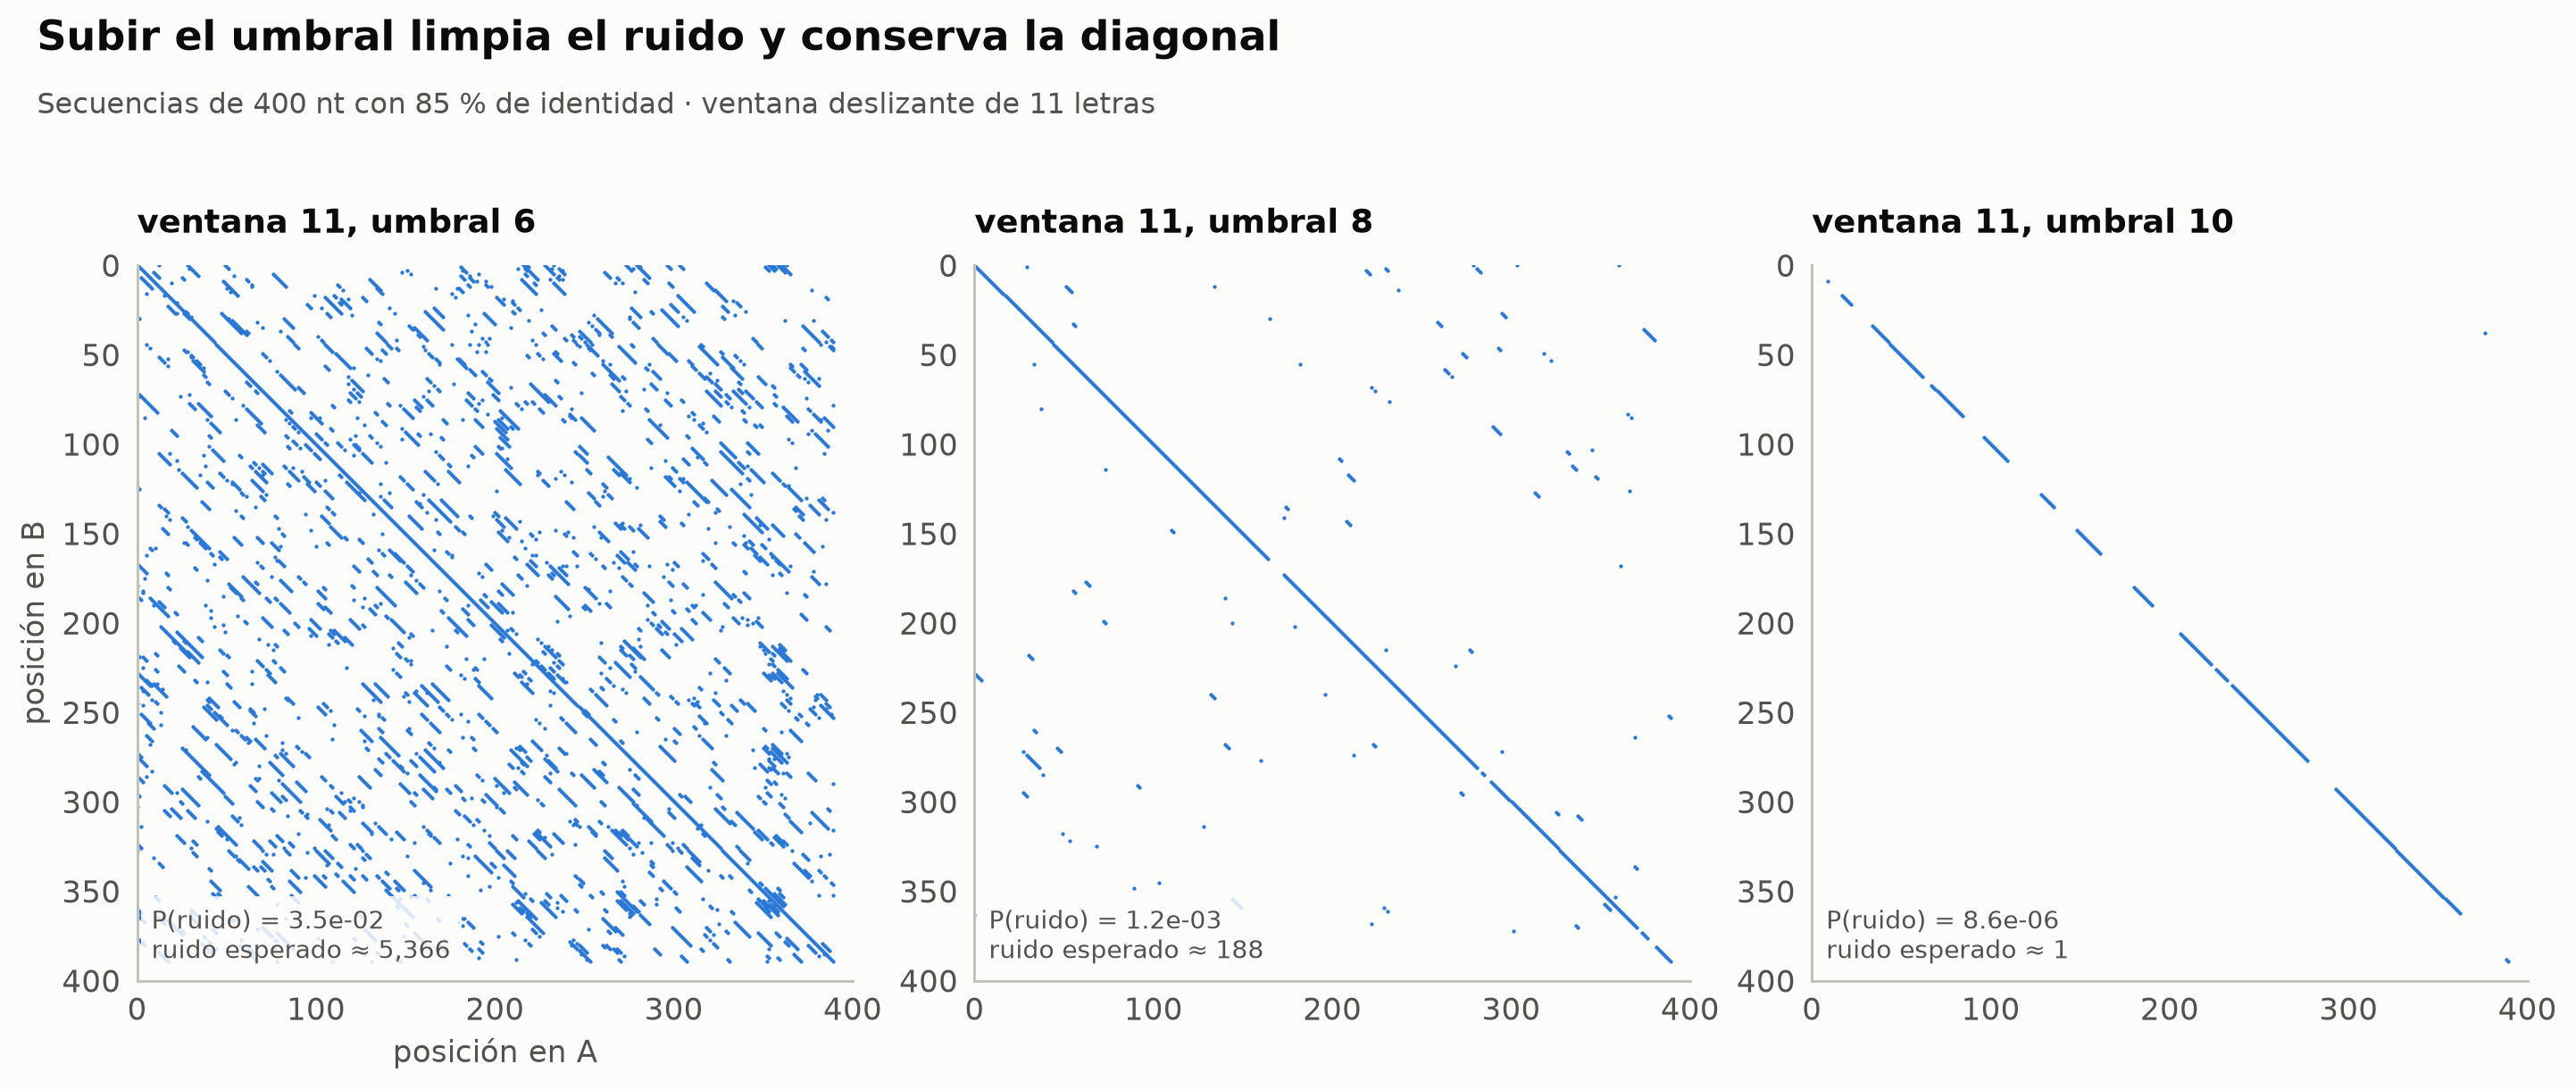

In [9]:
def window_scores(a: str, b: str, w: int) -> np.ndarray:
    """S[i, j] = número de coincidencias entre a[i:i+w] y b[j:j+w] (a lo largo de la diagonal)."""
    M = dot_matrix(a, b).astype(np.int32)
    C = np.zeros((M.shape[0] + 1, M.shape[1] + 1), dtype=np.int32)
    for i in range(M.shape[0]):                  # C[i+1, j+1] = M[i, j] + C[i, j]  (acumulado diagonal)
        C[i + 1, 1:] = C[i, :-1] + M[i]
    return C[w:, w:] - C[:-w, :-w]

from scipy import stats
w = 11
S = window_scores(a400, b400, w)
print("forma de S:", S.shape, "· máximo:", S.max())

fig, axes = plt.subplots(1, 3, figsize=(13, 4.9))
for ax, s in zip(axes, [6, 8, 10]):
    ii, jj = np.nonzero(S >= s)
    ax.scatter(ii, jj, s=2, color=ec.BLUE, lw=0, rasterized=True)
    p_noise = stats.binom.sf(s - 1, w, p_letter)
    ax.set_xlim(0, 400); ax.set_ylim(400, 0); ax.set_aspect("equal"); ax.grid(False)
    ax.set_title(f"ventana {w}, umbral {s}", fontsize=12)
    ax.text(0.02, 0.02, f"P(ruido) = {p_noise:.1e}\nruido esperado ≈ {S.size * p_noise:,.0f}",
            transform=ax.transAxes, fontsize=9, color=ec.INK_2, va="bottom",
            bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.85))
axes[0].set_xlabel("posición en A"); axes[0].set_ylabel("posición en B")
ec.fig_title(fig, "Subir el umbral limpia el ruido y conserva la diagonal",
             "Secuencias de 400 nt con 85 % de identidad · ventana deslizante de 11 letras")
plt.show()

> 🔎 **Qué observamos.** Con umbral 6 de 11 el ruido todavía es denso; con 8 de 11 la diagonal destaca y quedan
> pocas manchas; con 10 de 11 el fondo queda limpio, aunque la diagonal empieza a mostrar huecos donde se acumulan
> mutaciones. El número de puntos de ruido esperados (esquina inferior) coincide con lo que se ve.

Para elegir parámetros con criterio, grafiquemos la probabilidad de ruido para ADN y para proteínas:

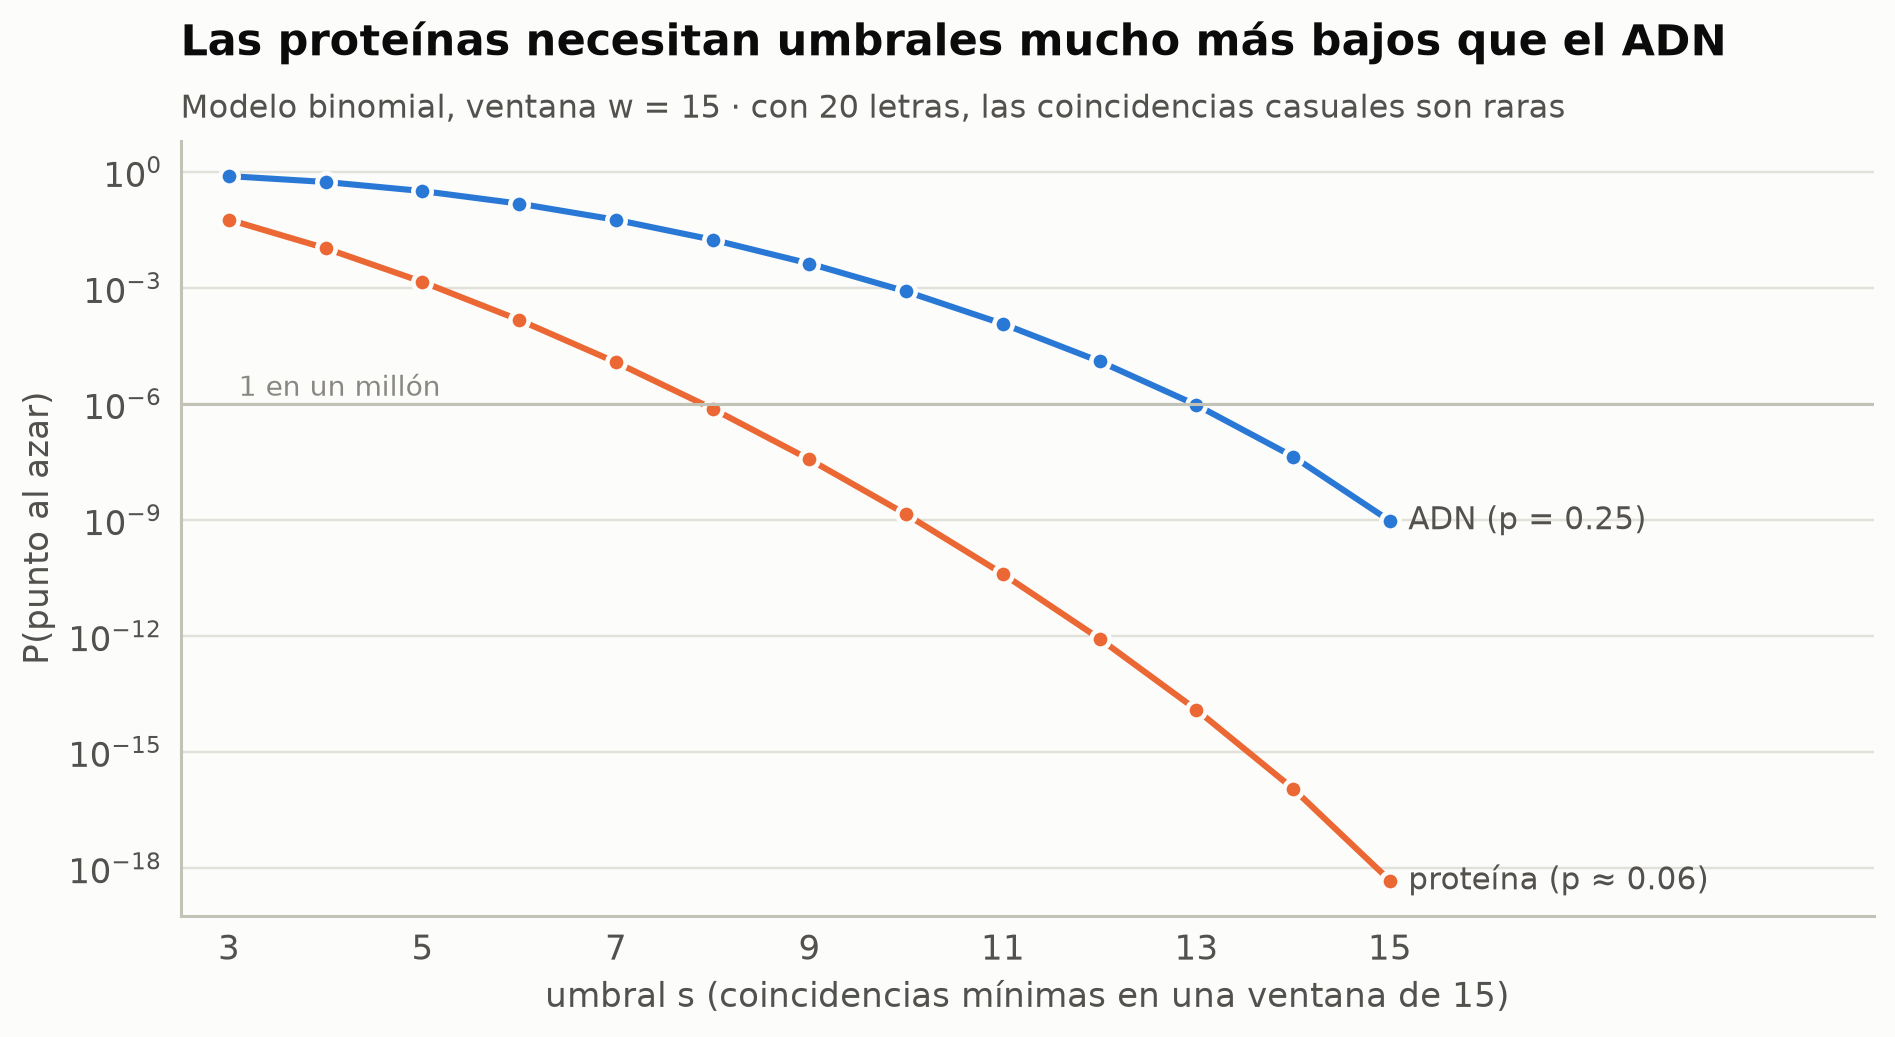

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
w = 15
s_vals = np.arange(3, w + 1)
for label, p, color in [("ADN (p = 0.25)", 0.25, ec.BLUE), ("proteína (p ≈ 0.06)", 0.06, ec.ORANGE)]:
    ax.semilogy(s_vals, stats.binom.sf(s_vals - 1, w, p), "o-", color=color, markersize=6,
                markeredgecolor=ec.SURFACE, markeredgewidth=1.5)
    ec.label_end(ax, s_vals[-1], stats.binom.sf(w - 1, w, p), label)
ax.axhline(1e-6, color=ec.BASELINE, lw=1)
ax.text(3.1, 1.6e-6, "1 en un millón", fontsize=9, color=ec.MUTED)
ax.set_xlim(2.5, w + 5); ax.set_xticks(range(3, w + 1, 2))
ax.set_xlabel(f"umbral s (coincidencias mínimas en una ventana de {w})")
ax.set_ylabel("P(punto al azar)")
ec.title(ax, "Las proteínas necesitan umbrales mucho más bajos que el ADN",
         f"Modelo binomial, ventana w = {w} · con 20 letras, las coincidencias casuales son raras")
plt.show()

> ✅ **Compruebe su comprensión.** Para ADN con ventana de 15, ¿qué umbral necesita para que la probabilidad de ruido
> sea menor que una en un millón? Léalo en la figura. ¿Y para proteínas? (Pista: busque dónde cada curva cruza la
> línea gris.) Esto explica por qué los programas usan parámetros distintos para ADN y proteínas.

## 6. 🧪 Experimento: SARS-CoV-2 frente a SARS-CoV-1

En 2003 el SARS-CoV-1 causó una epidemia; en 2019 apareció el SARS-CoV-2. Ambos son *betacoronavirus* con genomas
de ~30 000 nucleótidos y alrededor de 80 % de identidad. ¿Dónde se parecen y dónde divergieron? Una tabla de
$30\,000 \times 30\,000$ tiene 900 millones de casillas: no podemos construir la matriz completa, pero sí buscar
**palabras compartidas** con un diccionario (como en la sección 3), que sólo guarda los puntos.

¿Qué $k$ usar? Con $n = m \approx 30\,000$ y $p \approx 0.26$ (composición real), el ruido esperado con $k = 12$ es
$\approx 9\times10^8 \times 0.26^{12} \approx 9\times10^8 \times 9.5\times10^{-8} \approx 85$ puntos, frente a
miles de puntos de señal. Aceptable.

In [11]:
def load_genbank(acc: str):
    """Lee un GenBank: copia local del curso → NCBI → copia en GitHub."""
    local = f"../data/{acc}.gb"
    if os.path.exists(local):
        return SeqIO.read(local, "genbank")
    fn = f"{acc}.gb"
    if not os.path.exists(fn):
        try:
            with Entrez.efetch(db="nuccore", id=acc, rettype="gbwithparts", retmode="text") as h:
                open(fn, "w").write(h.read())
        except Exception as err:
            print("NCBI no respondió:", err, "→ copia del curso")
            urllib.request.urlretrieve(f"{RAW}/data/{acc}.gb", fn)
    return SeqIO.read(fn, "genbank")

sars2 = load_genbank("NC_045512.2")
sars1 = load_genbank("NC_004718.3")
s2, s1 = str(sars2.seq).upper(), str(sars1.seq).upper()
print(f"SARS-CoV-2: {len(s2):,} nt · SARS-CoV-1: {len(s1):,} nt")

def cds_table(rec):
    rows = []
    for f in rec.features:
        if f.type == "CDS":
            q = f.qualifiers
            rows.append({"gene": q.get("gene", q.get("product", ["?"]))[0],
                         "start": int(f.location.start), "end": int(f.location.end),
                         "product": q.get("product", [""])[0]})
    return pd.DataFrame(rows).drop_duplicates("gene")

genes2, genes1 = cds_table(sars2), cds_table(sars1)

k = 12
t0 = time.perf_counter()
x_f, y_f = kmer_matches(s2, s1, k, "+")
x_r, y_r = kmer_matches(s2, s1, k, "-")
comp = np.array([s2.count(c) for c in "ACGT"]) / len(s2)
p_real = float(np.sum(comp * np.array([s1.count(c) for c in "ACGT"]) / len(s1)))
print(f"palabras de {k} compartidas: misma hebra = {len(x_f):,} · hebra opuesta = {len(x_r):,}"
      f" · ruido esperado ≈ {(len(s2)-k+1)*(len(s1)-k+1)*p_real**k:,.0f} · {time.perf_counter()-t0:.1f} s")

SARS-CoV-2: 29,903 nt · SARS-CoV-1: 29,751 nt
palabras de 12 compartidas: misma hebra = 4,374 · hebra opuesta = 114 · ruido esperado ≈ 90 · 0.2 s


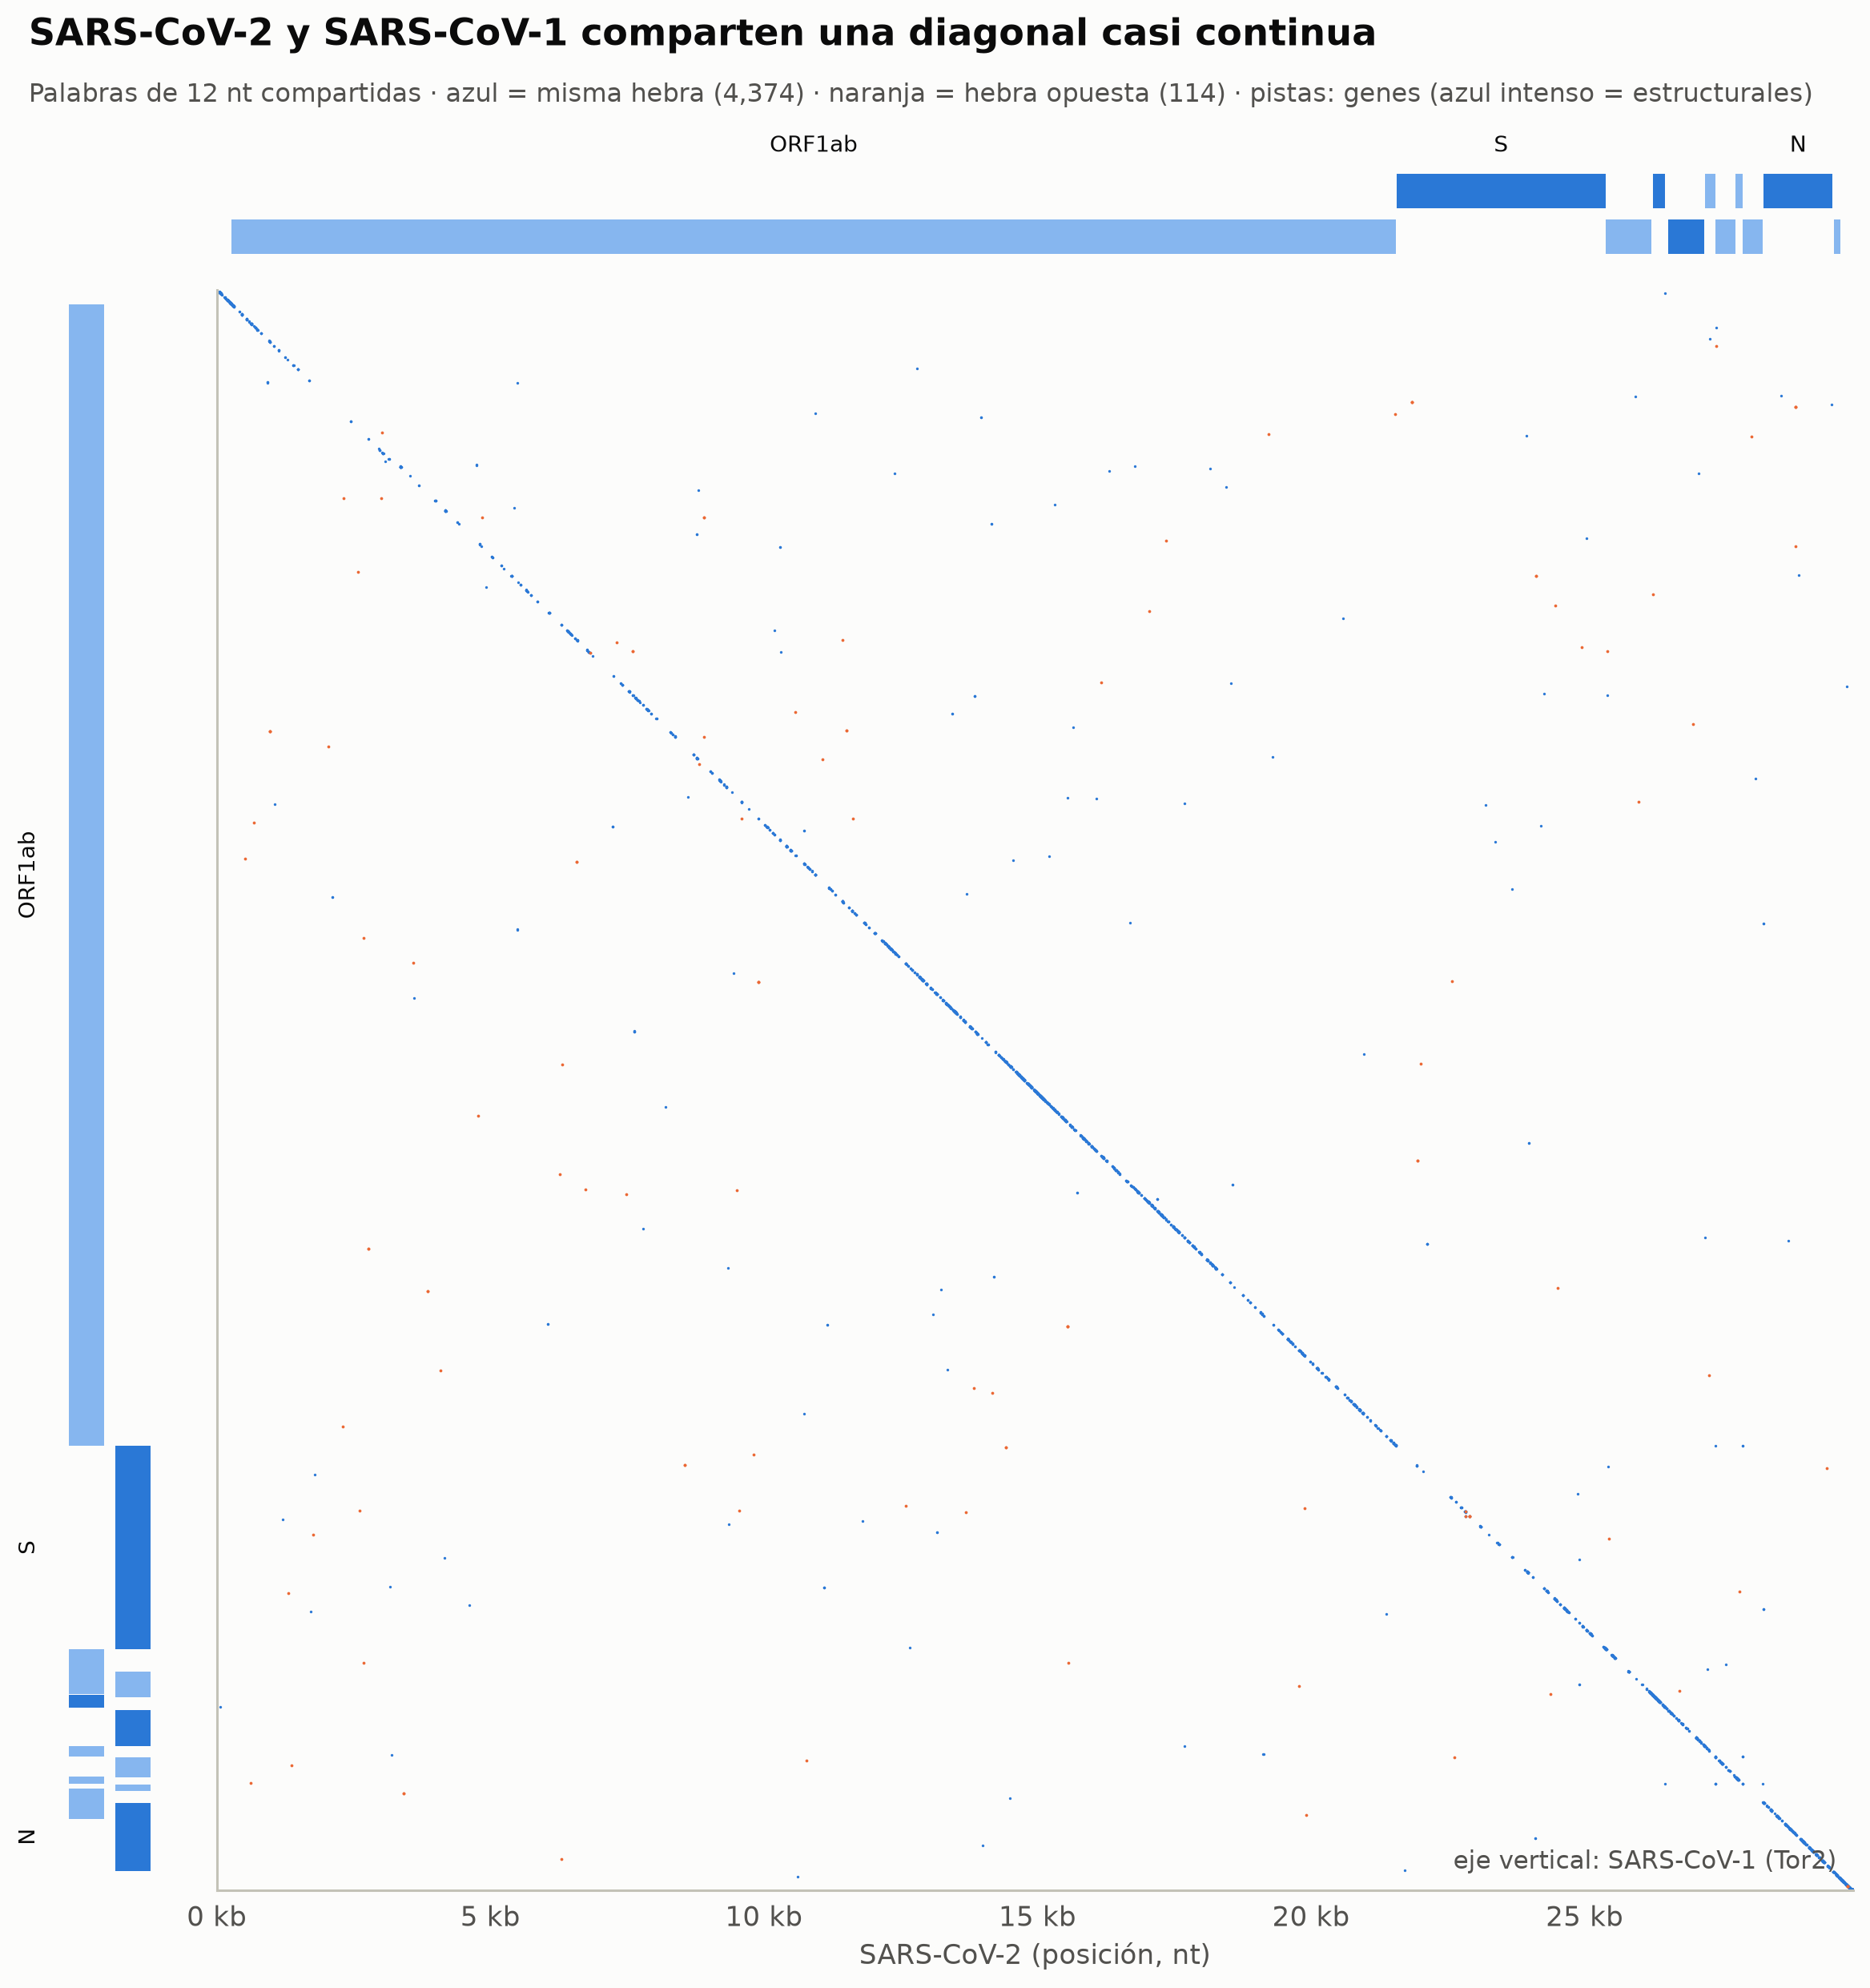

In [12]:
def gene_at(pos, genes):
    hit = genes[(genes.start <= pos) & (genes.end > pos)]
    return hit.gene.iloc[0] if len(hit) else "intergénica"

fig = plt.figure(figsize=(10.5, 10.5))
gs = GridSpec(2, 2, width_ratios=[1, 14], height_ratios=[1, 14], wspace=0.02, hspace=0.02, figure=fig)
ax = fig.add_subplot(gs[1, 1])
ax_top = fig.add_subplot(gs[0, 1], sharex=ax)
ax_left = fig.add_subplot(gs[1, 0], sharey=ax)

ax.scatter(x_f, y_f, s=1.2, color=ec.BLUE, lw=0, rasterized=True)
ax.scatter(x_r, y_r, s=1.5, color=ec.ORANGE, lw=0, rasterized=True)
ax.set_xlim(0, len(s2)); ax.set_ylim(len(s1), 0); ax.grid(False)
ax.set_xlabel("SARS-CoV-2 (posición, nt)"); ax.tick_params(labelleft=False)
fmt = plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb")
ax.xaxis.set_major_formatter(fmt)

def gene_track(axis, genes, horizontal):
    for i, r in genes.reset_index(drop=True).iterrows():
        color = ec.BLUE if r.gene in ("S", "E", "M", "N") else ec.SEQ_BLUE[3]
        if horizontal:
            axis.add_patch(plt.Rectangle((r.start, 0.15 + 0.4 * (i % 2)), r.end - r.start, 0.3, color=color, lw=0))
            if r.end - r.start > 1000:
                axis.text((r.start + r.end) / 2, 1.0, r.gene, ha="center", va="bottom", fontsize=9)
        else:
            axis.add_patch(plt.Rectangle((0.15 + 0.4 * (i % 2), r.start), 0.3, r.end - r.start, color=color, lw=0))
            if r.end - r.start > 1000:
                axis.text(-0.1, (r.start + r.end) / 2, r.gene, ha="right", va="center", fontsize=9, rotation=90)
    axis.axis("off")

gene_track(ax_top, genes2, True); ax_top.set_ylim(0, 1)
gene_track(ax_left, genes1, False); ax_left.set_xlim(0, 1)
ax_left.yaxis.set_major_formatter(fmt)
ax.text(0.99, 0.01, "eje vertical: SARS-CoV-1 (Tor2)", transform=ax.transAxes, ha="right", va="bottom",
        fontsize=10, color=ec.INK_2)
ec.fig_title(fig, "SARS-CoV-2 y SARS-CoV-1 comparten una diagonal casi continua",
             f"Palabras de {k} nt compartidas · azul = misma hebra ({len(x_f):,}) · naranja = hebra opuesta ({len(x_r):,}) · pistas: genes (azul intenso = estructurales)")
plt.show()

> 🔎 **Qué observamos.**
>
> * Una **diagonal casi continua** de esquina a esquina: los dos genomas tienen la **misma organización** (colinealidad):
>   ORF1ab, luego S, ORF3a, E, M, …, N, en el mismo orden. No hay grandes reordenamientos.
> * La diagonal **no es uniforme**: tiene tramos densos y tramos ralos. En el gen **S** se vuelve claramente más rala:
>   la proteína Spike, que el sistema inmune ataca y que se adapta al receptor de cada huésped, es de las regiones que
>   más cambió. En la región de ORF8 casi desaparece: en el aislado Tor2 de SARS-CoV-1 el gen está partido en ORF8a y
>   ORF8b, y en SARS-CoV-2 ORF8 es muy divergente. (Lo mediremos gen por gen en un momento.)
> * Los puntos sueltos fuera de la diagonal, azules y naranja, son **ruido**: encontramos 114 palabras compartidas
>   en la hebra opuesta cuando el azar predice unas 90. No hay inversiones, lo esperable en virus de ARN de cadena
>   simple positiva.

Ahora exploremos lo mismo **interactivamente**. Haga zoom sobre el gen S (arrastre un rectángulo alrededor de 21–25 kb)
y pase el cursor sobre los puntos: verá la palabra compartida exacta y el gen al que pertenece en cada genoma.

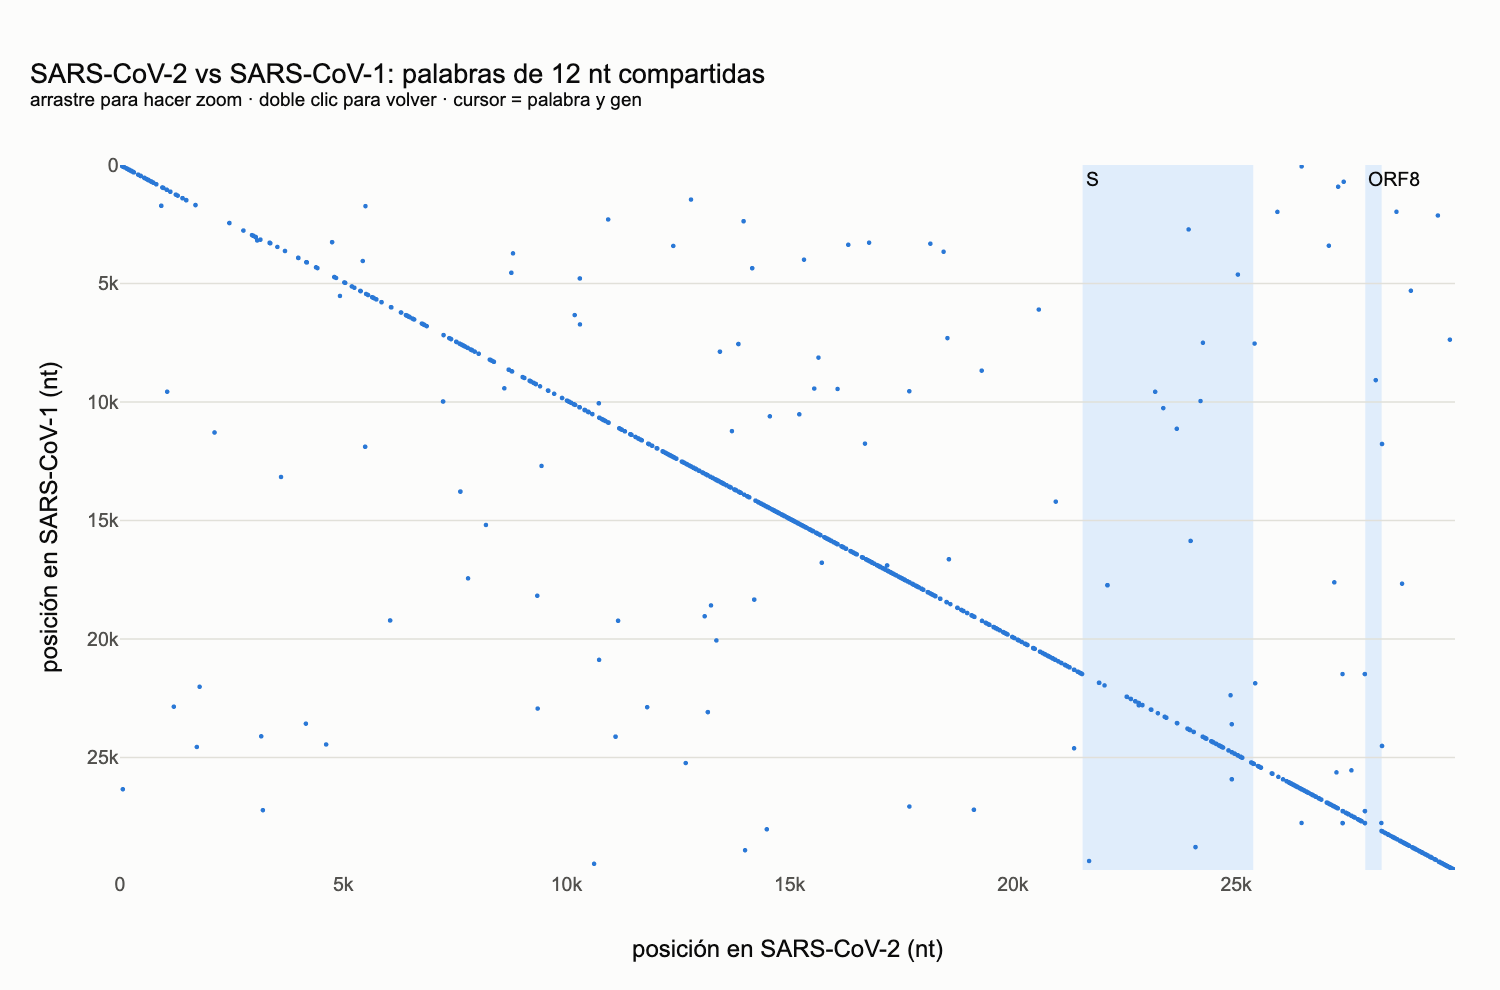

In [13]:
step = max(1, len(x_f) // 6000)                    # submuestreo para que el gráfico sea ágil
xs, ys = x_f[::step], y_f[::step]
hover = [f"<b>{s2[i:i+k]}</b><br>SARS-CoV-2: {i+1:,} ({gene_at(i, genes2)})"
         f"<br>SARS-CoV-1: {j+1:,} ({gene_at(j, genes1)})" for i, j in zip(xs, ys)]
fig = go.Figure(go.Scattergl(x=xs, y=ys, mode="markers", marker=dict(size=3, color=ec.BLUE),
                             hovertext=hover, hoverinfo="text", name="palabras compartidas"))
for _, r in genes2.iterrows():
    if r.gene in ("S", "ORF8"):
        fig.add_vrect(x0=r.start, x1=r.end, fillcolor=ec.SEQ_BLUE[0], opacity=0.6, line_width=0, layer="below",
                      annotation_text=r.gene, annotation_position="top left")
fig.update_layout(
    title=dict(text=f"SARS-CoV-2 vs SARS-CoV-1: palabras de {k} nt compartidas"
                    "<br><sup>arrastre para hacer zoom · doble clic para volver · cursor = palabra y gen</sup>"),
    height=660, width=680, margin=dict(t=110, l=80, r=30),
    xaxis=dict(title="posición en SARS-CoV-2 (nt)", range=[0, len(s2)], constrain="domain"),
    yaxis=dict(title="posición en SARS-CoV-1 (nt)", range=[len(s1), 0], constrain="domain"))
fig.show()

Cuantifiquemos lo que el ojo vio: la **densidad de puntos diagonales por gen** es una medida aproximada de
conservación (más palabras de 12 intactas ⇒ menos mutaciones).

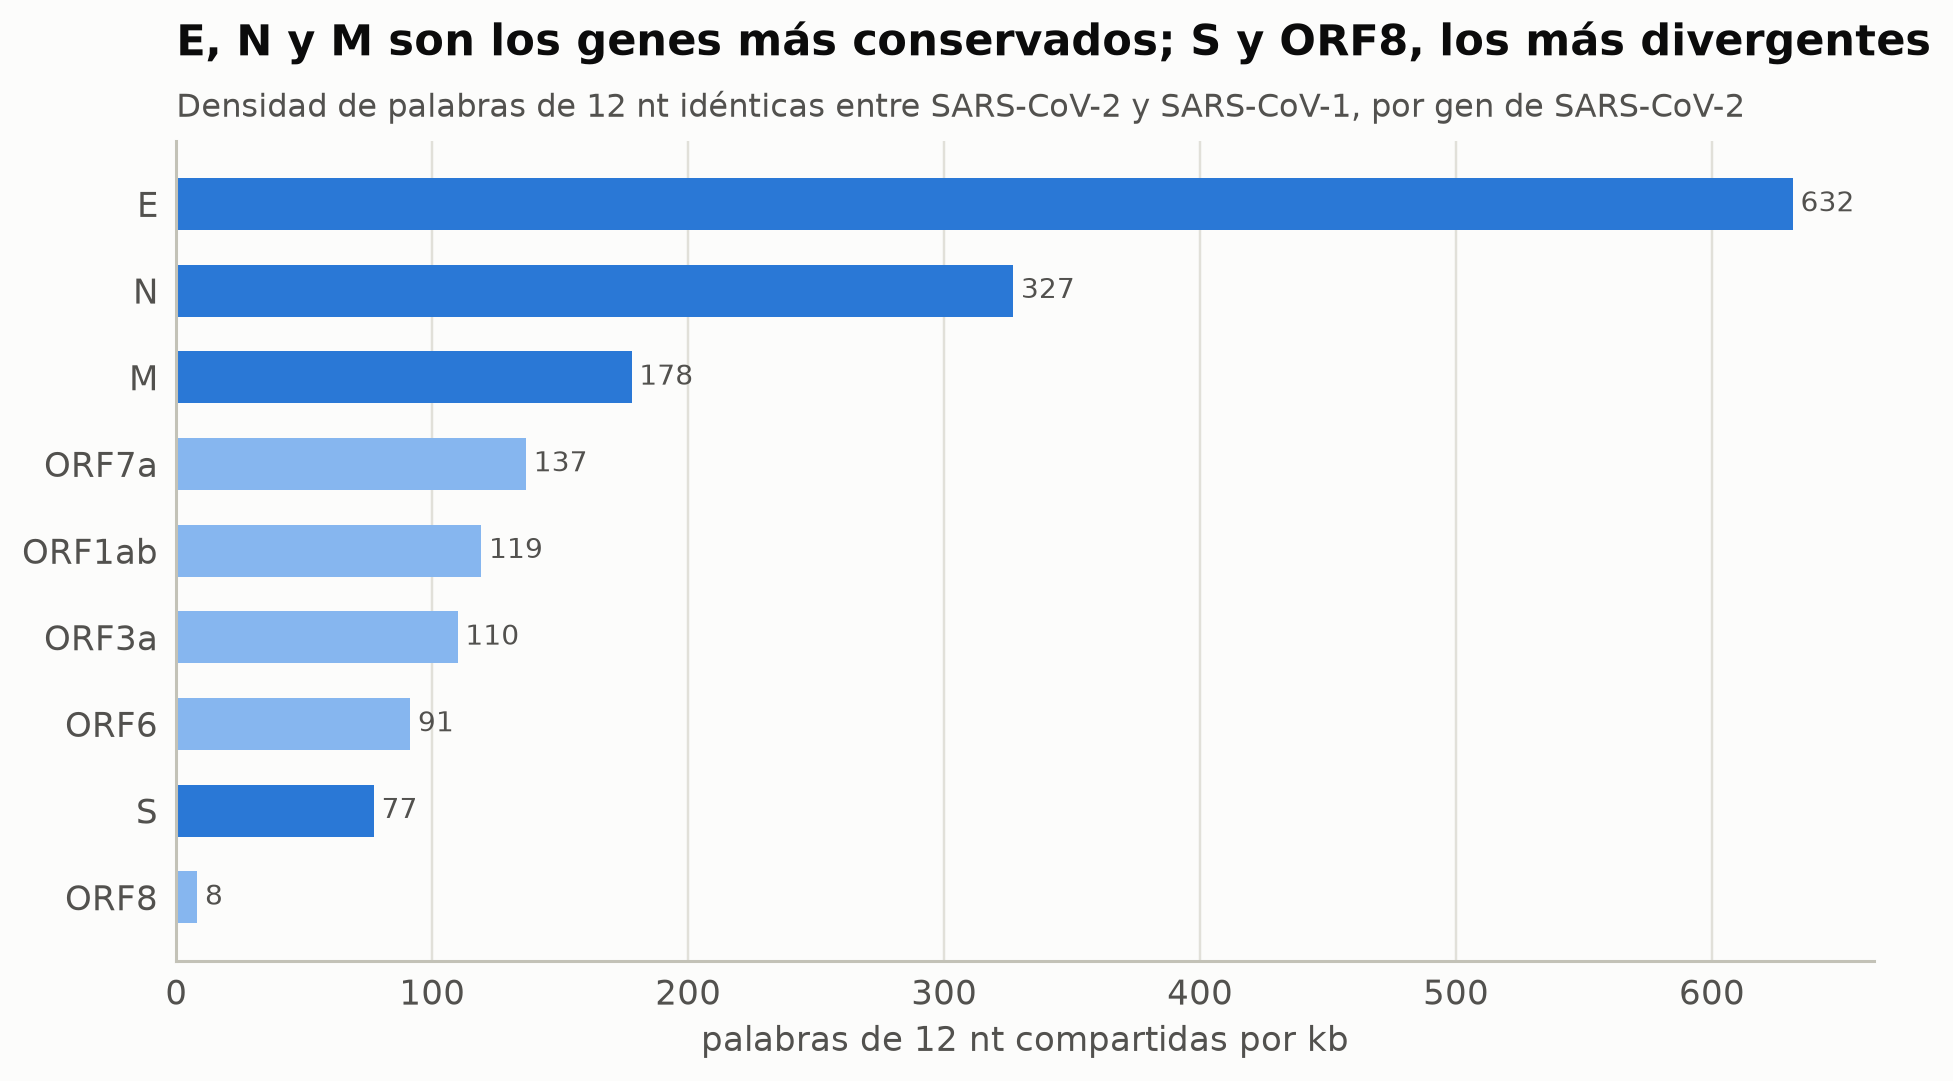

In [14]:
# Puntos "sobre la diagonal": los que están cerca de la línea que une los genes homólogos
rows = []
for _, r in genes2.iterrows():
    in_gene = (x_f >= r.start) & (x_f < r.end)
    rows.append({"gene": r.gene, "length_nt": r.end - r.start,
                 "shared_12mers_per_kb": 1000 * in_gene.sum() / (r.end - r.start)})
dens = pd.DataFrame(rows).query("length_nt > 150").sort_values("shared_12mers_per_kb")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = [ec.BLUE if g in ("S", "E", "M", "N") else ec.SEQ_BLUE[3] for g in dens.gene]
ax.barh(dens.gene, dens.shared_12mers_per_kb, color=colors, height=0.6)
for yv, v in enumerate(dens.shared_12mers_per_kb):
    ax.text(v + 3, yv, f"{v:.0f}", va="center", fontsize=9, color=ec.INK_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("palabras de 12 nt compartidas por kb")
ec.title(ax, "E, N y M son los genes más conservados; S y ORF8, los más divergentes",
         "Densidad de palabras de 12 nt idénticas entre SARS-CoV-2 y SARS-CoV-1, por gen de SARS-CoV-2")
plt.show()

## 7. 🧪 Experimento: las repeticiones internas de la calmodulina

Un *dot plot* de una secuencia **contra sí misma** es una radiografía de su arquitectura interna. La diagonal principal
es trivial (toda secuencia se parece a sí misma); lo interesante son las **diagonales secundarias**, que revelan
fragmentos repetidos.

La **calmodulina** es una proteína pequeña (149 aminoácidos) que actúa como sensor de calcio en todas las células
eucariotas. Tiene cuatro dominios "mano EF" (*EF-hand*): cada uno es un bucle de 12 residuos que atrapa un ion
$\mathrm{Ca}^{2+}$. Se cree que la proteína surgió por **duplicaciones génicas** de un dominio ancestral; si eso es
cierto, sus cuatro manos deberían parecerse entre sí.

Con proteínas usamos ventanas: 20 letras hacen que $p$ sea pequeño (≈ 0.06–0.08), así que una ventana de 12 con
umbral 5 ya deja poco ruido. La celda siguiente calcula $p$ para la calmodulina real y la probabilidad de ruido
$P(X\ge5)$ con el modelo binomial.

In [15]:
def load_uniprot_fasta(acc: str) -> str:
    """Secuencia de UniProt: caché del curso → UniProt REST → copia en GitHub."""
    local = f"../data/api_cache/uniprot_{acc}.fasta"
    if os.path.exists(local):
        text = open(local).read()
    else:
        try:
            text = urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{acc}.fasta", timeout=30).read().decode()
        except Exception as err:
            print("UniProt no respondió:", err, "→ copia del curso")
            text = urllib.request.urlopen(f"{RAW}/data/api_cache/uniprot_{acc}.fasta").read().decode()
    header, *seq = text.strip().splitlines()
    print(header)
    return "".join(seq)

calm = load_uniprot_fasta("P0DP23")
wp, sp = 12, 5
Sc = window_scores(calm, calm, wp)
p_prot = sum((calm.count(x) / len(calm)) ** 2 for x in set(calm))
p_noise_c = stats.binom.sf(sp - 1, wp, p_prot)
print(f"longitud = {len(calm)} aa · p = {p_prot:.3f} · P(ruido) = {p_noise_c:.1e}"
      f" · ruido esperado ≈ {Sc.size * p_noise_c:.0f} puntos en {Sc.size:,} ventanas")

>sp|P0DP23|CALM1_HUMAN Calmodulin-1 OS=Homo sapiens OX=9606 GN=CALM1 PE=1 SV=1
longitud = 149 aa · p = 0.075 · P(ruido) = 1.2e-03 · ruido esperado ≈ 23 puntos en 19,044 ventanas


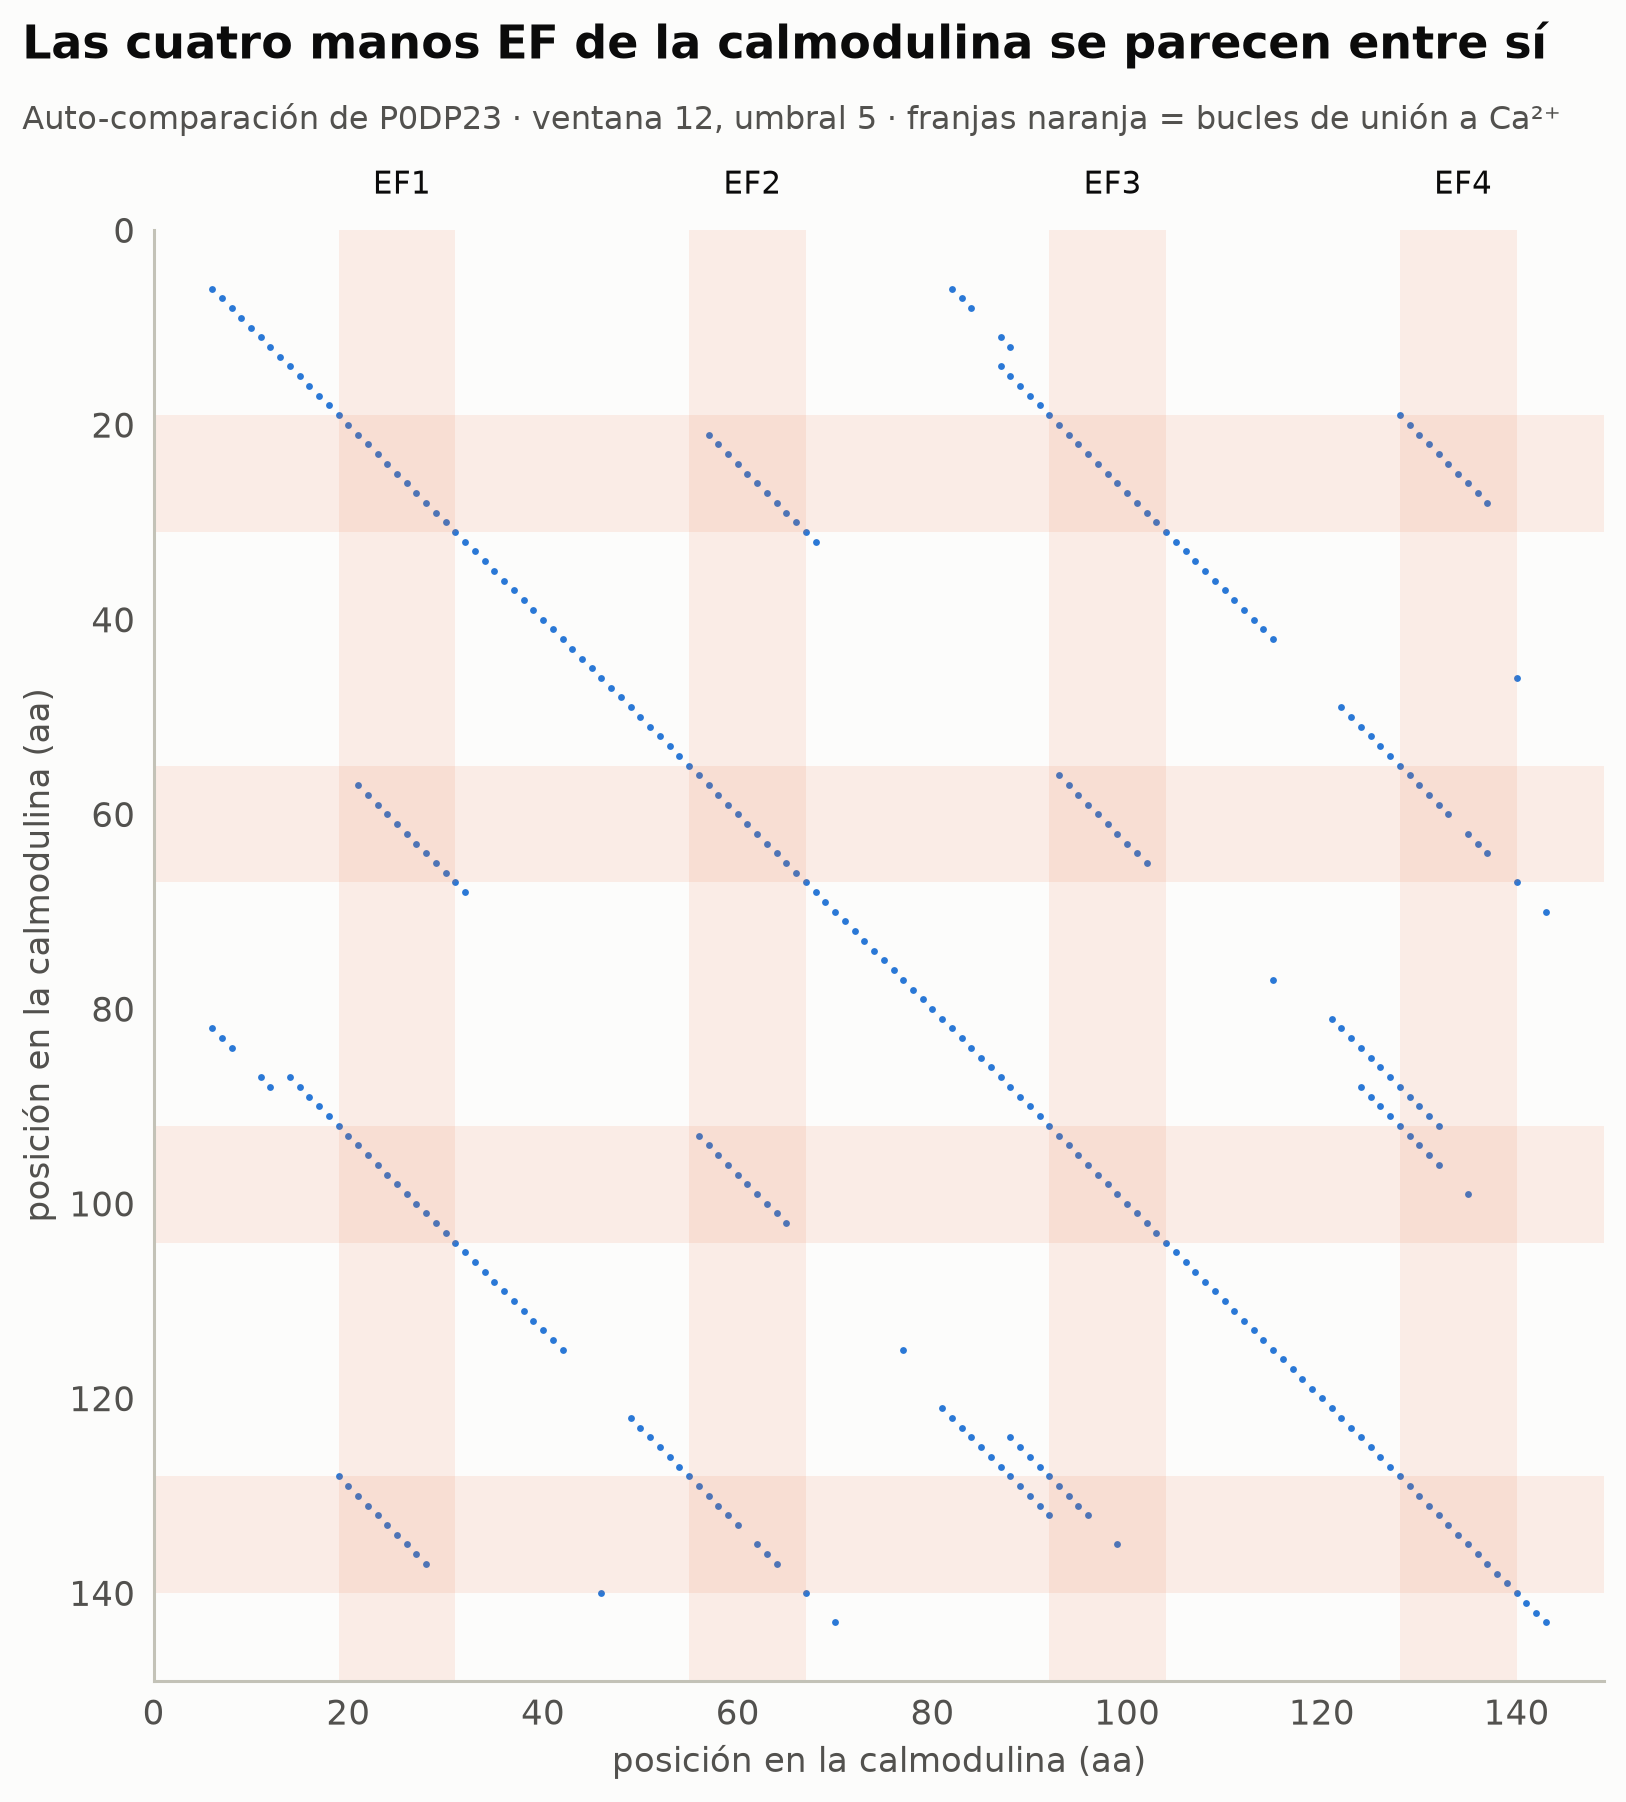

In [16]:
ef_loops = [(20, 31), (56, 67), (93, 104), (129, 140)]   # bucles de unión a Ca2+ (1-based, UniProt)
fig, ax = plt.subplots(figsize=(7.4, 7.4))
ii, jj = np.nonzero(Sc >= sp)
ax.scatter(ii + wp / 2, jj + wp / 2, s=5, color=ec.BLUE, lw=0)
for k_, (s0, e0) in enumerate(ef_loops, 1):
    ax.axvspan(s0 - 1, e0, color=ec.ORANGE, alpha=0.10, lw=0)
    ax.axhspan(s0 - 1, e0, color=ec.ORANGE, alpha=0.10, lw=0)
    ax.text((s0 + e0) / 2, -3, f"EF{k_}", ha="center", va="bottom", fontsize=10, color=ec.INK)
ax.set_xlim(0, len(calm)); ax.set_ylim(len(calm), 0); ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("posición en la calmodulina (aa)"); ax.set_ylabel("posición en la calmodulina (aa)")
ec.fig_title(fig, "Las cuatro manos EF de la calmodulina se parecen entre sí",
             f"Auto-comparación de P0DP23 · ventana {wp}, umbral {sp} · franjas naranja = bucles de unión a Ca²⁺")
plt.show()

> 🔎 **Qué observamos.** Además de la diagonal principal aparecen segmentos diagonales **fuera** de ella, justo donde se
> cruzan las franjas naranja: el bucle EF1 se parece al EF2, al EF3 y al EF4. Los más claros suelen unir EF1 con EF3 y
> EF2 con EF4, lo que coincide con la hipótesis de una **duplicación doble**: un dominio ancestral se duplicó (dos
> manos) y luego ese par se volvió a duplicar (cuatro manos). La figura es simétrica respecto a la diagonal porque
> comparamos la proteína consigo misma.
> Los pocos puntos aislados que no forman segmentos son el ruido que predijo el modelo binomial.

En la versión interactiva el color indica **cuántas** coincidencias hay en cada ventana, y al pasar el cursor verá las
dos ventanas de 12 aminoácidos que se están comparando, una sobre la otra.

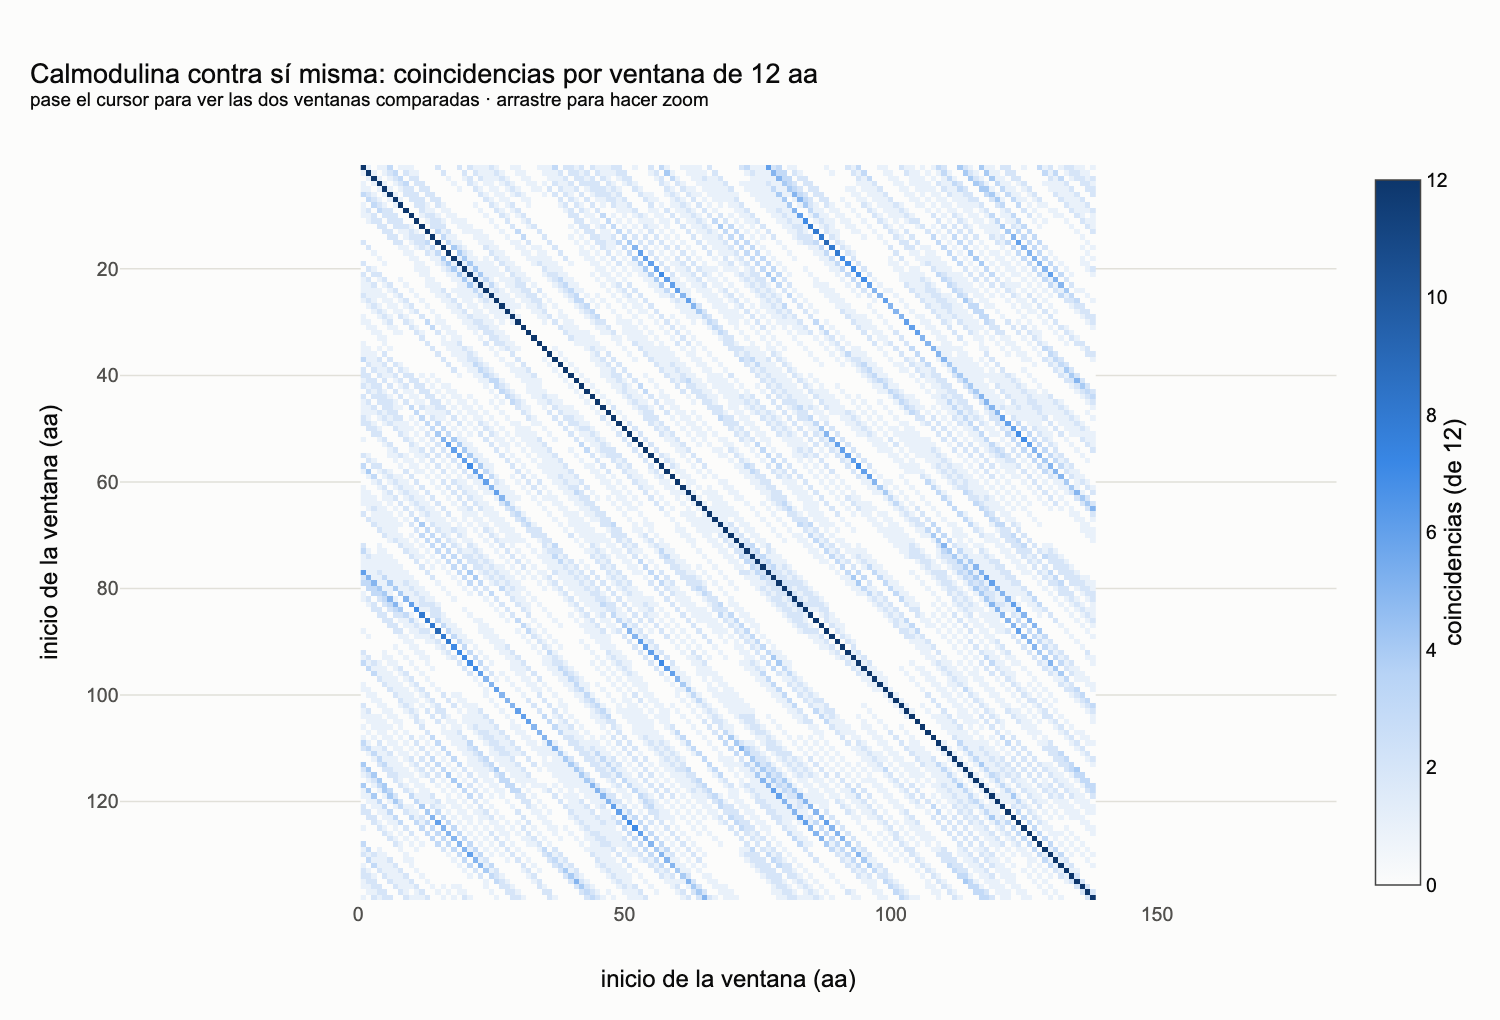

In [17]:
nwin = Sc.shape[0]
wins = [calm[i:i + wp] for i in range(nwin)]
custom = np.array([[f"{wins[i]}<br>{wins[j]}" for i in range(nwin)] for j in range(nwin)])
fig = go.Figure(go.Heatmap(
    z=Sc.T, x=np.arange(1, nwin + 1), y=np.arange(1, nwin + 1), customdata=custom,
    colorscale=[[0, ec.SURFACE], [0.3, ec.SEQ_BLUE[1]], [0.6, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[12]]],
    zmin=0, zmax=wp, colorbar=dict(title=dict(text="coincidencias (de 12)", side="right")),
    hovertemplate="ventana A (inicio %{x}):<br><span style='font-family:monospace'>%{customdata}</span>"
                  "<br>coincidencias: %{z} de 12<extra></extra>"))
fig.update_layout(
    title=dict(text="Calmodulina contra sí misma: coincidencias por ventana de 12 aa"
                    "<br><sup>pase el cursor para ver las dos ventanas comparadas · arrastre para hacer zoom</sup>"),
    height=680, width=720, margin=dict(t=110),
    xaxis=dict(title="inicio de la ventana (aa)"),
    yaxis=dict(title="inicio de la ventana (aa)", autorange="reversed", scaleanchor="x"))
fig.show()

## 8. 🧪 Horquillas y palíndromos: comparar una secuencia con su complemento reverso

Una hebra de ADN o ARN puede **doblarse sobre sí misma** si contiene un tramo seguido, un poco más adelante, de su
complemento reverso: las dos partes se aparean y forman un **tallo**, con un **lazo** en la punta. Estas horquillas
(*hairpins*) son señales biológicas importantes: por ejemplo, los **terminadores de la transcripción** en bacterias son
horquillas ricas en GC seguidas de una cola de U.

¿Cómo detectarlas? Comparando la secuencia **consigo misma pero en la hebra opuesta**: el tallo aparecerá como una
**antidiagonal** naranja que se aleja de la diagonal principal.

Un caso extremo son los **palíndromos** de ADN, como el sitio de la enzima de restricción EcoRI, `GAATTC`: su
complemento reverso es **él mismo** (`GAATTC` → complemento `CTTAAG` → al revés `GAATTC`).

revcomp('GAATTC') = GAATTC ← palíndromo
secuencia de 156 nt con un tallo de 12 nt en la posición 61


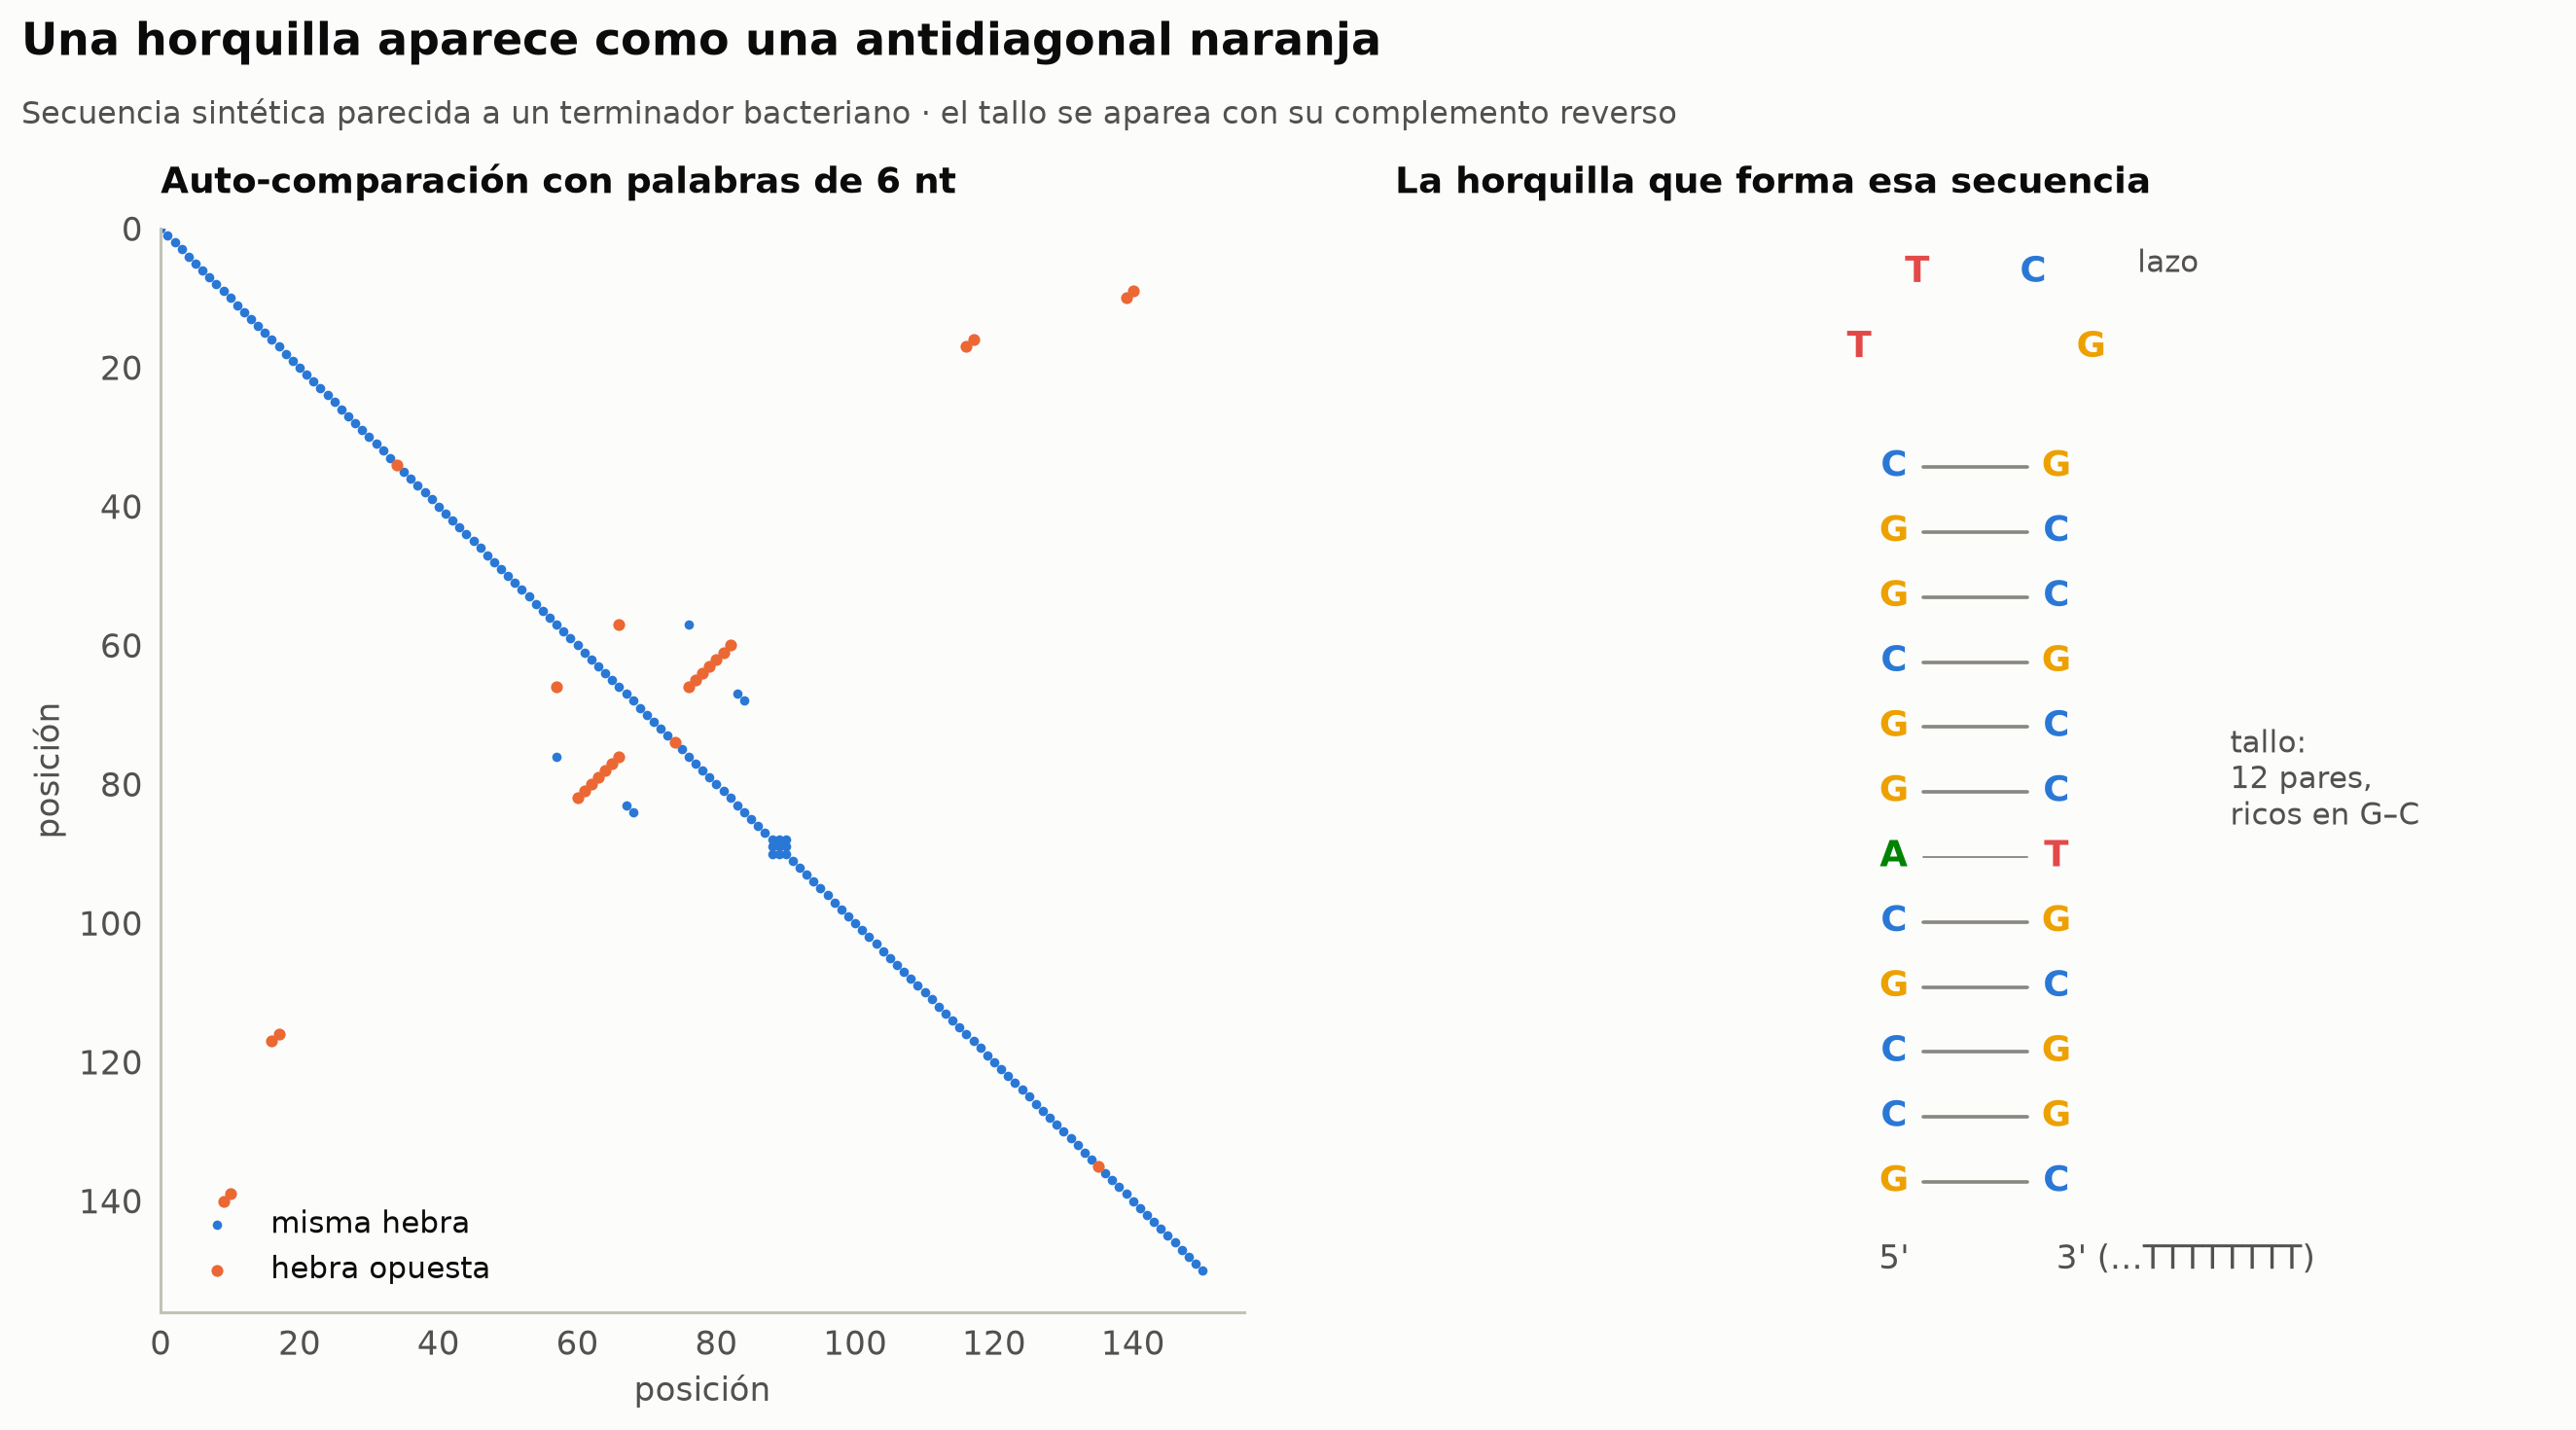

In [18]:
rng = np.random.default_rng(8)
stem = "GCCGCAGGCGGC"                                    # tallo rico en GC (12 nt)
loop = "TTCG"
hairpin_seq = random_dna(60, rng) + stem + loop + revcomp(stem) + "TTTTTTTT" + random_dna(60, rng)
print("revcomp('GAATTC') =", revcomp("GAATTC"), "← palíndromo")
print(f"secuencia de {len(hairpin_seq)} nt con un tallo de {len(stem)} nt en la posición 61")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.9), width_ratios=[1.15, 1])
ax = axes[0]
kh = 6
x, y = kmer_matches(hairpin_seq, hairpin_seq, kh, "+")
ax.scatter(x, y, s=10, color=ec.BLUE, lw=0, label="misma hebra")
x, y = kmer_matches(hairpin_seq, hairpin_seq, kh, "-")
ax.scatter(x, y, s=16, color=ec.ORANGE, lw=0, label="hebra opuesta")
ax.set_xlim(0, len(hairpin_seq)); ax.set_ylim(len(hairpin_seq), 0); ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("posición"); ax.set_ylabel("posición")
ax.legend(loc="lower left")
ax.set_title(f"Auto-comparación con palabras de {kh} nt", fontsize=12)

# Esquema de la horquilla
ax = axes[1]; ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 10)
for i, (b1, b2) in enumerate(zip(stem, revcomp(stem)[::-1])):
    yv = 1.2 + i * 0.6
    ax.text(4.3, yv, b1, ha="center", va="center", fontsize=12, fontweight="bold", color=ec.NUC_COLORS[b1])
    ax.text(5.7, yv, b2, ha="center", va="center", fontsize=12, fontweight="bold", color=ec.NUC_COLORS[b2])
    ax.plot([4.55, 5.45], [yv, yv], color=ec.MUTED, lw=1.2 if b1 in "GC" else 0.6)
for i, bl in enumerate(loop):
    ang = np.pi * (1 - i / (len(loop) - 1))
    ax.text(5 + 1.0 * np.cos(ang), 1.2 + len(stem) * 0.6 + 0.5 + 0.8 * np.sin(ang), bl, ha="center",
            va="center", fontsize=12, fontweight="bold", color=ec.NUC_COLORS[bl])
ax.text(4.3, 0.4, "5'", ha="center", fontsize=11, color=ec.INK_2)
ax.text(5.7, 0.4, "3' (…TTTTTTTT)", ha="left", fontsize=11, color=ec.INK_2)
ax.text(7.2, 4.5, "tallo:\n12 pares,\nricos en G–C", fontsize=10, color=ec.INK_2)
ax.text(6.4, 9.6, "lazo", fontsize=10, color=ec.INK_2)
ax.set_title("La horquilla que forma esa secuencia", fontsize=12)
ec.fig_title(fig, "Una horquilla aparece como una antidiagonal naranja",
             "Secuencia sintética parecida a un terminador bacteriano · el tallo se aparea con su complemento reverso")
plt.show()

> 🔎 **Qué observamos.** El pequeño segmento naranja perpendicular a la diagonal une las posiciones ~61–72 con ~77–88:
> el tallo "se ve a sí mismo" en la hebra opuesta. La distancia entre los dos brazos es el tamaño del lazo. En la
> Lección 13 buscaremos este tipo de estructuras de forma sistemática.

## 9. Lo que un *dot plot* no puede decirnos

El *dot plot* es la mejor herramienta **exploratoria** que existe: no presupone nada, muestra todas las relaciones a la
vez (similitudes, repeticiones, inversiones, reordenamientos) y el ojo humano detecta patrones de manera asombrosa.
Pero tiene tres limitaciones que motivan el resto del módulo:

| Limitación | Consecuencia | Lo resolveremos en… |
|---|---|---|
| **No da un número** | "Se parecen bastante" no es una respuesta científica | 3.2: puntaje de alineamiento |
| **No dice cuál es la correspondencia exacta** letra a letra, ni dónde poner los huecos | no podemos contar mutaciones ni inferir la proteína ancestral | 3.2: Needleman-Wunsch y Smith-Waterman |
| **No mide la significancia** | ¿un parecido de 30 % es evolución o azar? | 3.3–3.4: matrices de sustitución y estadística de BLAST |

Además, el costo crece como el **producto** de las longitudes: la tabla completa de dos genomas humanos tendría
$(3\times10^9)^2 \approx 10^{19}$ casillas. Por eso los programas modernos usan exactamente el truco de las
**palabras compartidas** de la sección 5 (buscar "semillas" en un índice) y sólo después examinan las regiones
prometedoras. Ésa es la idea central de **BLAST** (Lección 3.4) y de los alineadores de lecturas (Módulo 7).

In [19]:
sizes = pd.DataFrame({
    "comparación": ["dos genes (1 kb)", "dos virus (30 kb)", "dos bacterias (5 Mb)", "dos genomas humanos (3 Gb)"],
    "n": [1e3, 3e4, 5e6, 3.1e9],
})
sizes["casillas"] = sizes["n"] ** 2
sizes["memoria (1 bit por casilla)"] = (sizes["casillas"] / 8).map(
    lambda B: f"{B:.0f} B" if B < 1e3 else f"{B/1e3:.0f} kB" if B < 1e6 else f"{B/1e6:.0f} MB" if B < 1e9
    else f"{B/1e9:.1f} GB" if B < 1e12 else f"{B/1e18:.1f} EB")
sizes.style.format({"n": "{:,.0f}", "casillas": "{:.1e}"}).hide(axis="index")

comparación,n,casillas,memoria (1 bit por casilla)
dos genes (1 kb),"1,000",1.0e+06,125 kB
dos virus (30 kb),"30,000",9.0e+08,112 MB
dos bacterias (5 Mb),"5,000,000",2.5e+13,0.0 EB
dos genomas humanos (3 Gb),"3,100,000,000",9.6e+18,1.2 EB


## ✍️ Ejercicios

**Ejercicio 1 — La firma del colágeno.** El colágeno tipo I (UniProt `P02452`) está formado por el triplete
repetido `Gly-X-Y`. Haga un *dot plot* de la región 180–480 contra sí misma con ventana 9 y umbral 5. ¿Qué patrón
espera? ¿A qué distancia deberían estar las diagonales paralelas?

**Ejercicio 2 — Ruido en proteínas.** Dos proteínas no relacionadas de 300 aminoácidos, con $p = 0.06$. ¿Cuántos
puntos de ruido espera con palabras de $k = 1, 2, 3$? ¿Qué $k$ elegiría?

**Ejercicio 3 — Diseñar el filtro.** Para ADN con ventana $w = 15$, encuentre el umbral $s$ más bajo tal que el ruido
esperado en una comparación de dos secuencias de 10 000 nt sea menor que 1 punto.

**Ejercicio 4 — ¿Hay horquillas grandes en SARS-CoV-2?** Compare el genoma de SARS-CoV-2 consigo mismo en la hebra
opuesta con palabras de 12 nt. ¿Cuántos puntos encuentra y cuántos esperaría por azar? ¿Qué concluye?

>sp|P02452|CO1A1_HUMAN Collagen alpha-1(I) chain OS=Homo sapiens OX=9606 GN=COL1A1 PE=1 SV=6


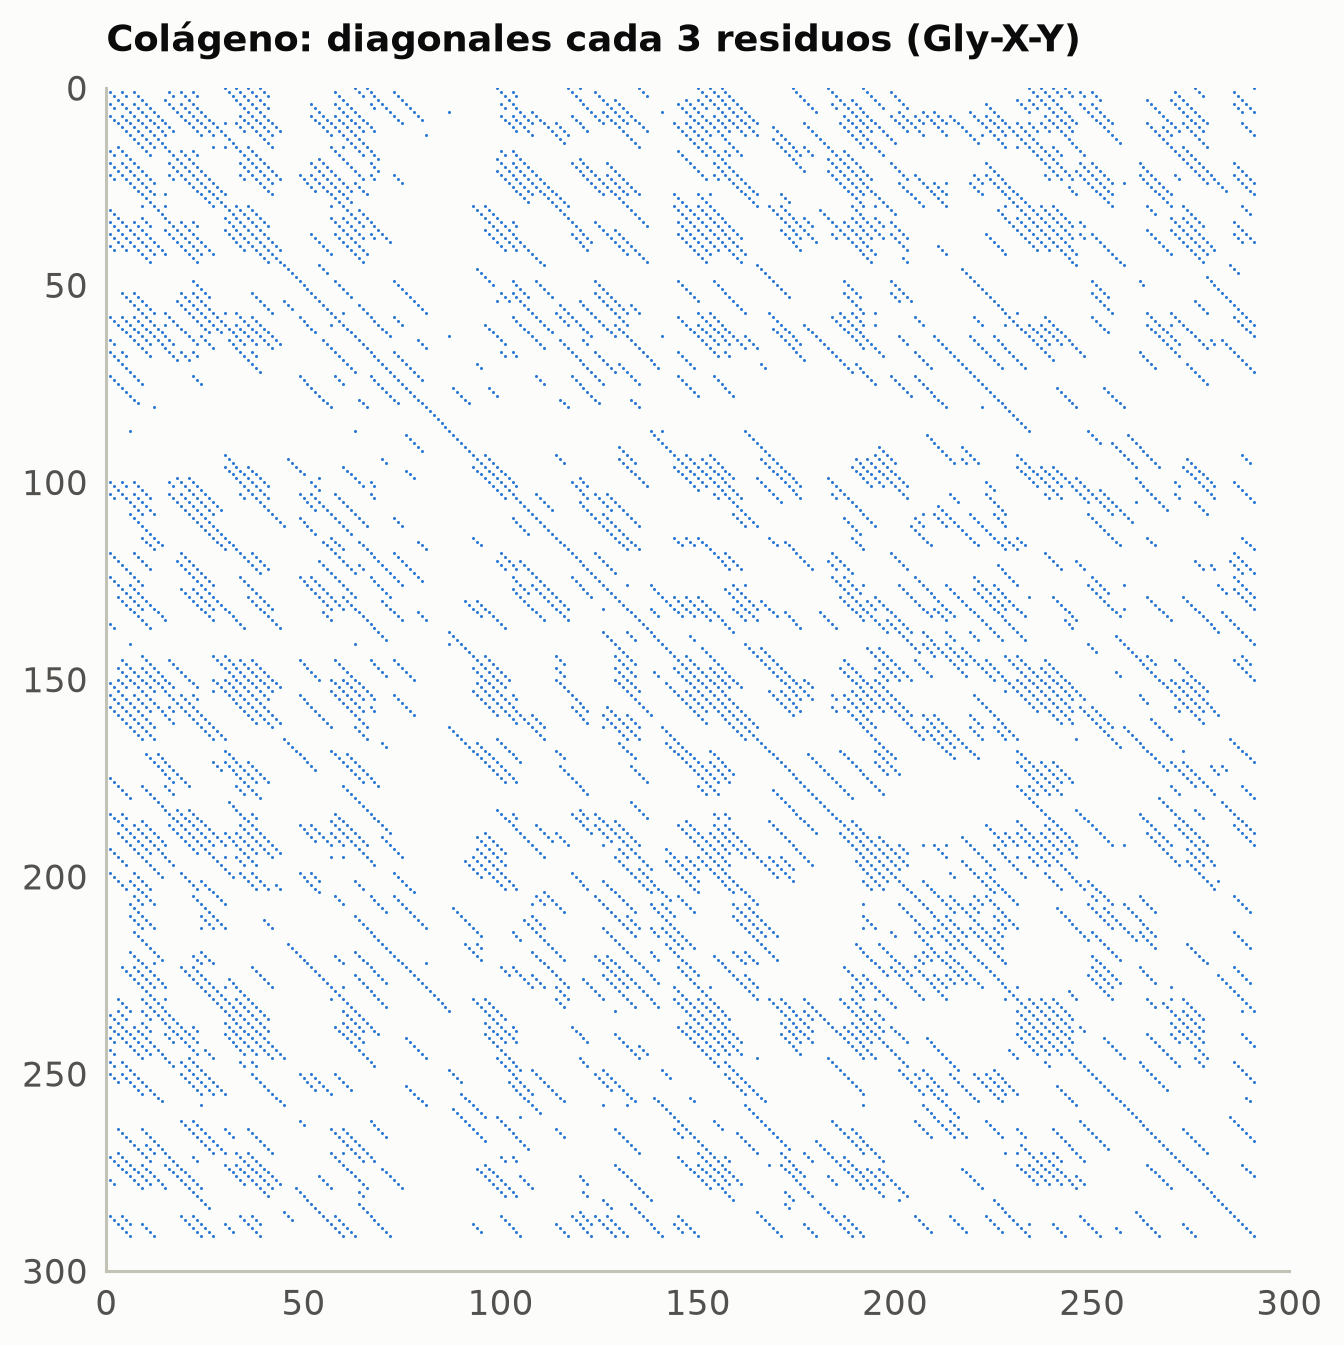

desplazamientos más frecuentes: [np.int64(51), np.int64(3), np.int64(33), np.int64(36), np.int64(6), np.int64(15)] → múltiplos de 3


In [20]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
col = load_uniprot_fasta("P02452")[180:480]
Scol = window_scores(col, col, 9)
ii, jj = np.nonzero(Scol >= 5)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ii, jj, s=1, color=ec.BLUE, lw=0)
ax.set_xlim(0, len(col)); ax.set_ylim(len(col), 0); ax.set_aspect("equal"); ax.grid(False)
ax.set_title("Colágeno: diagonales cada 3 residuos (Gly-X-Y)", loc="left", fontsize=12)
plt.show()
offsets = Counter((jj - ii)[(jj - ii) > 0])
print("desplazamientos más frecuentes:", [d for d, _ in offsets.most_common(6)], "→ múltiplos de 3")

In [21]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for k_ in (1, 2, 3):
    print(f"k = {k_}: {(301 - k_) ** 2 * 0.06 ** k_:,.1f} puntos al azar")
print("Con k = 3 el ruido cae a ~19 puntos: es un valor típico para proteínas (BLASTP usa palabras de 3).")

k = 1: 5,400.0 puntos al azar
k = 2: 321.8 puntos al azar
k = 3: 19.2 puntos al azar
Con k = 3 el ruido cae a ~19 puntos: es un valor típico para proteínas (BLASTP usa palabras de 3).


In [22]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
cells = (10_000 - 15 + 1) ** 2
for s_ in range(8, 16):
    expected = cells * stats.binom.sf(s_ - 1, 15, 0.25)
    print(f"s = {s_:2d}: ruido esperado = {expected:12,.2f}")
    if expected < 1:
        print(f"→ el umbral mínimo es s = {s_} de 15")
        break

s =  8: ruido esperado = 1,725,143.27
s =  9: ruido esperado =   418,128.22
s = 10: ruido esperado =    79,272.47
s = 11: ruido esperado =    11,501.32
s = 12: ruido esperado =     1,232.96
s = 13: ruido esperado =        92.04
s = 14: ruido esperado =         4.27
s = 15: ruido esperado =         0.09
→ el umbral mínimo es s = 15 de 15


In [23]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
xr, yr = kmer_matches(s2, s2, 12, "-")
exp_r = (len(s2) - 11) ** 2 * p_real ** 12
print(f"puntos en la hebra opuesta: {len(xr)} · esperados por azar ≈ {exp_r:.0f}")
print("Del mismo orden que el azar: no hay grandes repeticiones invertidas; las estructuras de ARN del virus"
      " son horquillas cortas (< 12 nt de tallo perfecto) que requieren métodos de plegamiento, no dot plots.")

puntos en la hebra opuesta: 135 · esperados por azar ≈ 91
Del mismo orden que el azar: no hay grandes repeticiones invertidas; las estructuras de ARN del virus son horquillas cortas (< 12 nt de tallo perfecto) que requieren métodos de plegamiento, no dot plots.


## 📌 Resumen

* Un *dot plot* marca las casillas $(i, j)$ donde $A_i = B_j$; la **similitud aparece como diagonales**.
* Patrones: diagonal desplazada = inserción/deleción; diagonales paralelas = repeticiones en tándem; antidiagonal en
  la hebra opuesta = inversión u horquilla; bloque = baja complejidad; segmentos en otras esquinas = reordenamiento.
* El ruido tiene una fórmula: $p = \sum p_x^2$ por casilla; con palabras de $k$ letras, $p^k$; con ventanas, la cola
  de una **binomial**. Cada letra extra divide el ruido de ADN por 4.
* Elegir $k$ o $(w, s)$ es negociar entre **ruido** y **sensibilidad** ($q^k$).
* SARS-CoV-2 y SARS-CoV-1 son **colineales**; la mayor divergencia está en S y ORF8.
* La calmodulina muestra sus **cuatro manos EF** duplicadas.
* Los *dot plots* no dan puntajes, correspondencias exactas ni significancia: para eso, **alineamos** (Lección 3.2).

## 📚 Para profundizar

* Gibbs, A. J. & McIntyre, G. A. (1970). The diagram, a method for comparing sequences. Its use with amino acid and
  nucleotide sequences. *European Journal of Biochemistry* 16: 1–11.
* Maizel, J. V. & Lenk, R. P. (1981). Enhanced graphic matrix analysis of nucleic acid and protein sequences.
  *PNAS* 78(12): 7665–7669.
* Krumsiek, J., Arnold, R. & Rattei, T. (2007). Gepard: a rapid and sensitive tool for creating dotplots on genome
  scale. *Bioinformatics* 23(8): 1026–1028.
* Durbin, R., Eddy, S., Krogh, A. & Mitchison, G. (1998). *Biological Sequence Analysis*. Cambridge University Press.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)